# Running Differential Transcription Analysis for WSP 2.5

In [1]:
library(data.table)
library(stringr)
# plotting
library(ggplot2)
library(cowplot)
# DE analysis
#library(limma)
library(edgeR)
library(DESeq2)
library(UpSetR)
library(gridExtra)
library(clusterProfiler)
library(org.Hs.eg.db)

Warning message:
"package 'data.table' was built under R version 4.4.1"
Warning message:
"package 'edgeR' was built under R version 4.4.1"
Cargando paquete requerido: limma

Warning message:
"package 'limma' was built under R version 4.4.1"
Cargando paquete requerido: S4Vectors

Warning message:
"package 'S4Vectors' was built under R version 4.4.1"
Cargando paquete requerido: stats4

Cargando paquete requerido: BiocGenerics


Adjuntando el paquete: 'BiocGenerics'


The following object is masked from 'package:limma':

    plotMA


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, s

ERROR: Error: package or namespace load failed for 'clusterProfiler':
 package 'AnnotationDbi' was installed before R 4.0.0: please re-install it


In [2]:
# save the results and TFEA input
results_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP/results/"
tfea_input_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP/data/TFEA_input/"

## 1. Get counts

In [3]:
# read in preliminary 5ptrunc counts
# the 
count_dir="/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP//data/counts/"
genes_file=paste0(count_dir, "fixed_genes_CUWA_WSP_3.26.25_counts.txt")
gene_counts <- fread(genes_file)
gene_counts[1:2,]

# get easier names
colnames(gene_counts) <- c("Geneid", "Chr", "Start", "End", "Strand", "Length", 
                           "Veh_1", "Veh_2", "WSP30_1", "WSP30_2", "WSP120_1", "WSP120_2")
# get the gene name (not just isoform)
gene_counts$Gene <- str_split_fixed(gene_counts$Geneid, ":", 2)[,1]
nrow(gene_counts)
length(unique(gene_counts$Gene))

# only keep the non-putative Refseq genes
nonput <- fread("/Users/hopekirby/Desktop/TF_Enh_Linking/Final_Project_Repos/Bidir_Counting_Analysis/assets/hg38_refseq_diff53prime_5ptrunc_counting.bed")
nonput$Gene <- str_split_fixed(nonput$V4, ":", 2)[,1]
nrow(nonput)
length(unique(nonput$Gene))
nonput[1:2,]
# look at some of the names that are putative
setdiff(gene_counts$Gene, nonput$Gene)[1:3]
gene_counts <- gene_counts[gene_counts$Gene %in% nonput$Gene,]
nrow(gene_counts)
length(unique(gene_counts$Gene))

Geneid,Chr,Start,End,Strand,Length,./mmfiltbams/SRR13772348.mmfilt.sorted.bam,./mmfiltbams/SRR13772349.mmfilt.sorted.bam,./mmfiltbams/SRR13772350.mmfilt.sorted.bam,./mmfiltbams/SRR13772351.mmfilt.sorted.bam,./mmfiltbams/SRR13772352.mmfilt.sorted.bam,./mmfiltbams/SRR13772353.mmfilt.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
PLK1:NM_005030.6,chr16,23680792,23690367,+,9576,3195,3518,2394,2469,3759,4007
COP1:NM_022457.7,chr1,175944830,176205393,-,260564,6770,6657,7730,8048,11801,14798


[1] 42130

[1] 28800

[1] 42224

[1] 28889

V1,V2,V3,V4,V5,V6,Gene
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,12623,14409,DDX11L1:NR_046018.2,.,+,DDX11L1
chr1,14361,28620,WASH7P:NR_024540.1,.,-,WASH7P


[1] NA NA NA

[1] 42130

[1] 28800

In [4]:
# filter according to counts
# remove genes with counts (< 70 across all AND length > 3000) AND < 40
gene_counts$sum_counts <- rowSums(gene_counts[,c("Veh_1", "Veh_2", "WSP30_1", "WSP30_2", "WSP120_1", "WSP120_2")])
length(unique(gene_counts$Gene))

# Get the most transcribed isoforms of each
kept_isoforms <- c()
# get the length normalized counts 
gene_counts$LNC <- gene_counts$sum_counts/gene_counts$Length
gene_counts[1:2,]
# for each gene
for (gene in unique(gene_counts$Gene)) {
    # get the isoform with the highest Length normalized counts (LNC)
    filt = gene_counts[gene_counts$Gene == gene,]
    filt = filt[order(-filt$LNC),]
    kept_isoforms <- c(kept_isoforms, filt$Geneid[1])
    }
# ensure I'm keeping the right amount
length(kept_isoforms)
length(unique(gene_counts$Gene))

[1] 28800

Geneid,Chr,Start,End,Strand,Length,Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2,Gene,sum_counts,LNC
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
PLK1:NM_005030.6,chr16,23680792,23690367,+,9576,3195,3518,2394,2469,3759,4007,PLK1,19342,2.0198413
COP1:NM_022457.7,chr1,175944830,176205393,-,260564,6770,6657,7730,8048,11801,14798,COP1,55804,0.2141662


[1] 28800

[1] 28800

In [5]:
# FILTER COUNTS ACCORDING TO NUMBER OF READS
gene_counts <- gene_counts[gene_counts$Geneid %in% kept_isoforms,]
dim(gene_counts)
gene_counts[1:2,]

length(unique(gene_counts$Gene))
gene_filt_counts <- gene_counts[gene_counts$sum_counts > 49,]
gene_filt_counts <- gene_filt_counts[gene_filt_counts$sum_counts > 79 | gene_filt_counts$Length < 2000,]
length(unique(gene_filt_counts$Gene))

[1] 28800    15

Geneid,Chr,Start,End,Strand,Length,Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2,Gene,sum_counts,LNC
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
PLK1:NM_005030.6,chr16,23680792,23690367,+,9576,3195,3518,2394,2469,3759,4007,PLK1,19342,2.0198413
COP1:NM_022457.7,chr1,175944830,176205393,-,260564,6770,6657,7730,8048,11801,14798,COP1,55804,0.2141662


[1] 28800

[1] 18613

[1] 133

[1] 132  15

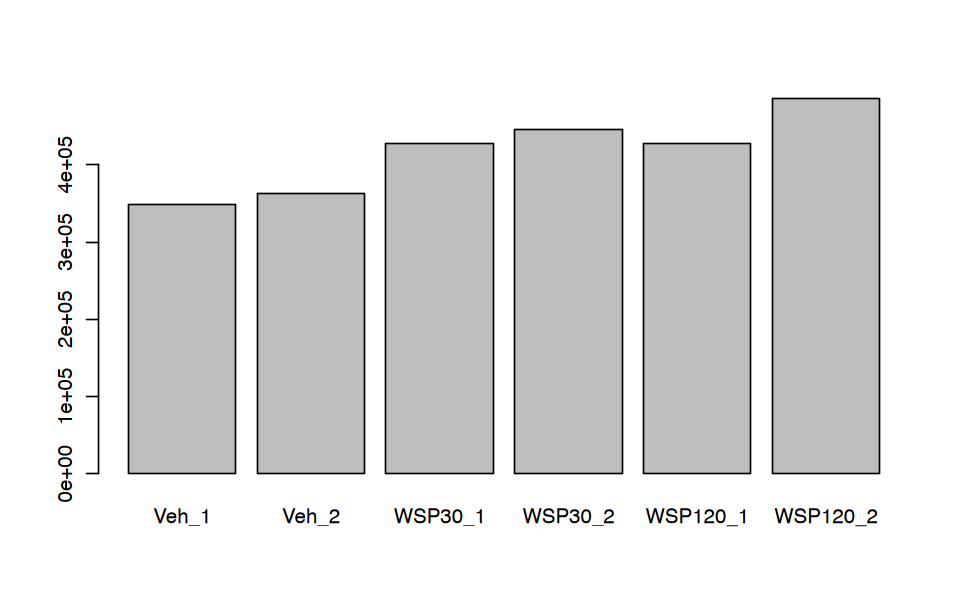

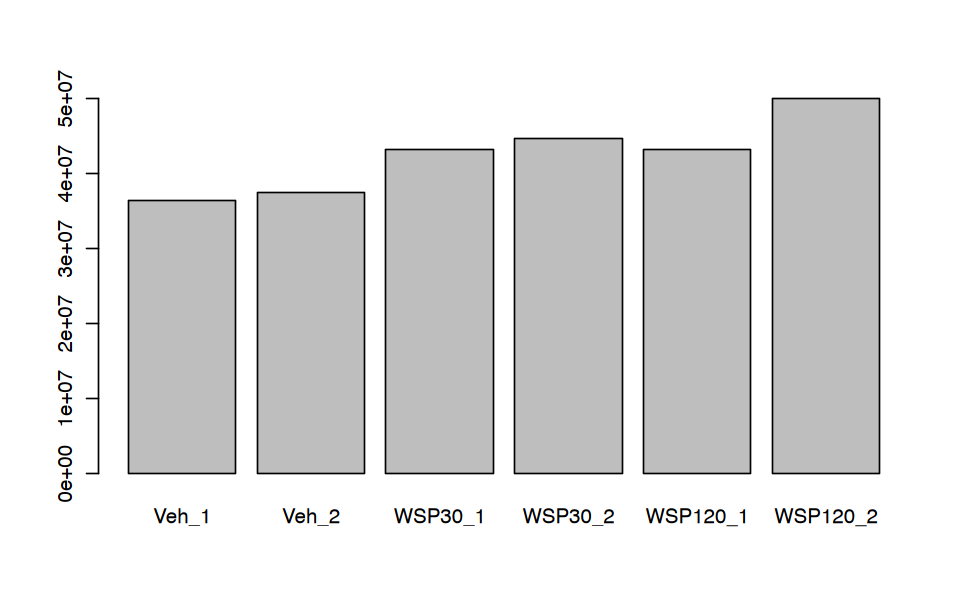

In [6]:
# check that the housekeeping genes are there
options(repr.plot.height=5, repr.plot.width=8)
hk_genes <- c(
  # Ribosomal genes (RPL and RPS families)
  "RPL3", "RPL4", "RPL5", "RPL6", "RPL7", "RPL8", "RPL9", "RPL10", "RPL10A", 
  "RPL11", "RPL12", "RPL13", "RPL13A", "RPL14", "RPL15", "RPL17", "RPL18", 
  "RPL18A", "RPL19", "RPL21", "RPL22", "RPL23", "RPL23A", "RPL24", "RPL26", 
  "RPL27", "RPL27A", "RPL28", "RPL29", "RPL30", "RPL31", "RPL32", "RPL34", 
  "RPL35", "RPL35A", "RPL36", "RPL36A", "RPL37", "RPL37A", "RPL38", "RPL39", 
  "RPS3", "RPS4X", "RPS4Y1", "RPS5", "RPS6", "RPS7", "RPS8", "RPS9", "RPS10", 
  "RPS11", "RPS12", "RPS13", "RPS14", "RPS15", "RPS15A", "RPS16", "RPS17", 
  "RPS18", "RPS19", "RPS20", "RPS21", "RPS23", "RPS24", "RPS25", "RPS26", 
  "RPS27", "RPS27A", "RPS28", "RPS29",

  # Translation factors (EEF, EIF, and GTPase families)
  "EEF1A1", "EEF1A2", "EEF1B2", "EEF1D", "EEF1G", "EEF2", "EIF1", "EIF2S1", 
  "EIF2S2", "EIF2S3", "EIF3A", "EIF3B", "EIF3C", "EIF3D", "EIF3E", "EIF3F", 
  "EIF3G", "EIF3H", "EIF3I", "EIF3J", "EIF3K", "EIF3L", "EIF3M", "EIF4A1", 
  "EIF4A2", "EIF4A3", "EIF4B", "EIF4E", "EIF4E1B", "EIF4E2", "EIF4E3", "EIF4G1", 
  "EIF4G2", "EIF4G3", "EIF5", "EIF5A", "EIF5B",

  # Transcription polymerase genes (RNA Polymerases)
  "POLR1A", "POLR1B", "POLR1C", "POLR1D", "POLR1E", "POLR2A", "POLR2B", 
  "POLR2C", "POLR2D", "POLR2E", "POLR2F", "POLR2G", "POLR2H", "POLR2I", 
  "POLR2J", "POLR2K", "POLR2L", "POLR3A", "POLR3B", "POLR3C", "POLR3D", 
  "POLR3E", "POLR3F", "POLR3G", "POLR3GL", "POLR3H"
)
length(hk_genes)
#length(intersect(gene_filt_counts$Gene, hk_genes))
gene_hk_counts <- gene_filt_counts[gene_filt_counts$Gene %in% hk_genes,]
dim(gene_hk_counts)
#gene_hk_counts
barplot(colSums(gene_hk_counts[,7:12]))
barplot(colSums(gene_counts[,7:12]))

### B. Bidirectionals

In [7]:
win_counts <- fread(paste0(count_dir, "fixed_full_bid_CUWA_WSP_3.26.25_counts.txt")) # TSS 18,017 & NonTSS 30,673

win_counts[1,]
# get easier names
colnames(win_counts) <- c("Geneid", "Chr", "Start", "End", "Strand", "Length", 
                           "Veh_1", "Veh_2", "WSP30_1", "WSP30_2", "WSP120_1", "WSP120_2")
# separate by tss and nontss bidirectionals
tss <- fread("/Users/hopekirby/Desktop/TF_Enh_Linking/Resp_Env/Comb_UPM_WSP_ADP//data/regions/tss_bid_CUWA_3.26.25.txt")
tss[1,]
tss_win_counts <- win_counts[win_counts$Geneid %in% tss$BidID,]
nontss_win_counts <- win_counts[!win_counts$Geneid %in% tss$BidID,]
nrow(tss_win_counts)
nrow(nontss_win_counts)

Geneid,Chr,Start,End,Strand,Length,./mmfiltbams/SRR13772348.mmfilt.sorted.bam,./mmfiltbams/SRR13772349.mmfilt.sorted.bam,./mmfiltbams/SRR13772350.mmfilt.sorted.bam,./mmfiltbams/SRR13772351.mmfilt.sorted.bam,./mmfiltbams/SRR13772352.mmfilt.sorted.bam,./mmfiltbams/SRR13772353.mmfilt.sorted.bam
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
chr1:632605-632763,chr1;chr1,632426;632684,632684;633684,-;+,1260,42,24,44,45,75,72


Chr,Bid_Start,Bid_Stop,BidID,Gene_Start,Gene_Stop,TranscriptID,Strand,mu,TSS,GeneID
<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>
chr1,629241,629291,chr1:629230-629302,628509,629509,LOC101928626:NR_125957.1,-,629266,629009,LOC101928626


[1] 14949

[1] 54065

## Get the matrix counts

In [8]:
# for easier naming, assign matrices back to counts
tss_win_counts_matrix <- as.matrix(tss_win_counts[, 7:12])
rownames(tss_win_counts_matrix) <- tss_win_counts$Geneid
dim(tss_win_counts_matrix)
tss_win_counts <- tss_win_counts_matrix

nontss_win_counts_matrix <- as.matrix(nontss_win_counts[, 7:12])
rownames(nontss_win_counts_matrix) <- nontss_win_counts$Geneid
nontss_win_counts_matrix[1:2,]
dim(nontss_win_counts_matrix)
nontss_win_counts <- nontss_win_counts_matrix


gene_counts_matrix <- as.matrix(gene_counts[, 7:12])
rownames(gene_counts_matrix) <- gene_counts$Gene
gene_counts_matrix[1:2,]
dim(gene_counts_matrix)
gene_counts <- gene_counts_matrix

gene_filt_counts_matrix <- as.matrix(gene_filt_counts[, 7:12])
rownames(gene_filt_counts_matrix) <- gene_filt_counts$Gene
gene_filt_counts_matrix[1:2,]
dim(gene_filt_counts_matrix)
gene_filt_counts <- gene_filt_counts_matrix

gene_hk_counts <- gene_filt_counts[intersect(hk_genes, rownames(gene_filt_counts)),]
dim(gene_hk_counts)

[1] 14949     6

,Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2
chr1:785582-786076,14,19,25,32,63,69
chr1:805310-805780,15,7,20,19,23,42


[1] 54065     6

,Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2
PLK1,3195,3518,2394,2469,3759,4007
COP1,6770,6657,7730,8048,11801,14798


[1] 28800     6

,Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2
PLK1,3195,3518,2394,2469,3759,4007
COP1,6770,6657,7730,8048,11801,14798


[1] 18613     6

[1] 132   6

### C. FIltering Bids based on counts

0%    25%    50%    75%   100% 
     0    373   3134   9177 280201

[1] 47341

[1] 30126

[1] 25779

0%   25%   50%   75%  100% 
    0     6    84   452 81818

0%  25%  50%  75% 100% 
   0    6   80  424 9994

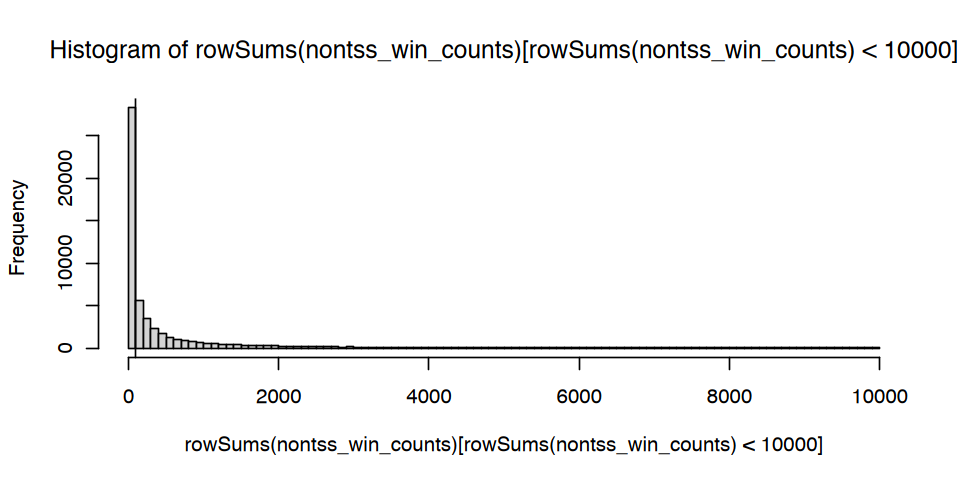

In [9]:
# exploring good cutoffs for enough transcription
quantile(rowSums(tss_win_counts))
length(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) > 0])
options(repr.plot.height=4)
hist(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) <  10000], breaks=120)
abline(v = 100)
length(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) > 50])
length(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) > 100])
quantile(rowSums(nontss_win_counts))
quantile(rowSums(nontss_win_counts)[rowSums(nontss_win_counts) < 10000])

In [10]:
old <- nrow(tss_win_counts)
tss_win_counts_filt = tss_win_counts[rowSums(tss_win_counts) > 25,]
cat("\nFixed TSS Bid: removed",old - nrow(tss_win_counts_filt), " Bid (", 
   nrow(tss_win_counts_filt), round(nrow(tss_win_counts_filt)/old, 3)*100, "% kept)")
# NonTSS Bid
old <- nrow(nontss_win_counts)
nontss_win_counts_filt = nontss_win_counts[rowSums(nontss_win_counts) > 25,]
cat("\nFixed nonTSS Bid: removed",old - nrow(nontss_win_counts_filt), " Bid (", 
   nrow(nontss_win_counts_filt), round(nrow(nontss_win_counts_filt)/old, 3)*100, "% kept)")



Fixed TSS Bid: removed 1522  Bid ( 13427 89.8 % kept)


Fixed nonTSS Bid: removed 20255  Bid ( 33810 62.5 % kept)

## 2. Design & PCA

In [11]:
design <- data.table("Name"=c("Veh_1", "Veh_2", "WSP30_1", "WSP30_2", "WSP120_1", "WSP120_2"), 
                    "Replicate"=c("1", "2", "1", "2", "1", "2"), 
                    "Treatment"=c("VEH", "VEH", "WSP30", "WSP30", "WSP120", "WSP120"))
design$Replicate <- as.factor(design$Replicate)
design$Treatment <- as.factor(design$Treatment)
design


Name,Replicate,Treatment
<chr>,<fct>,<fct>
Veh_1,1,VEH
Veh_2,2,VEH
WSP30_1,1,WSP30
WSP30_2,2,WSP30
WSP120_1,1,WSP120
WSP120_2,2,WSP120


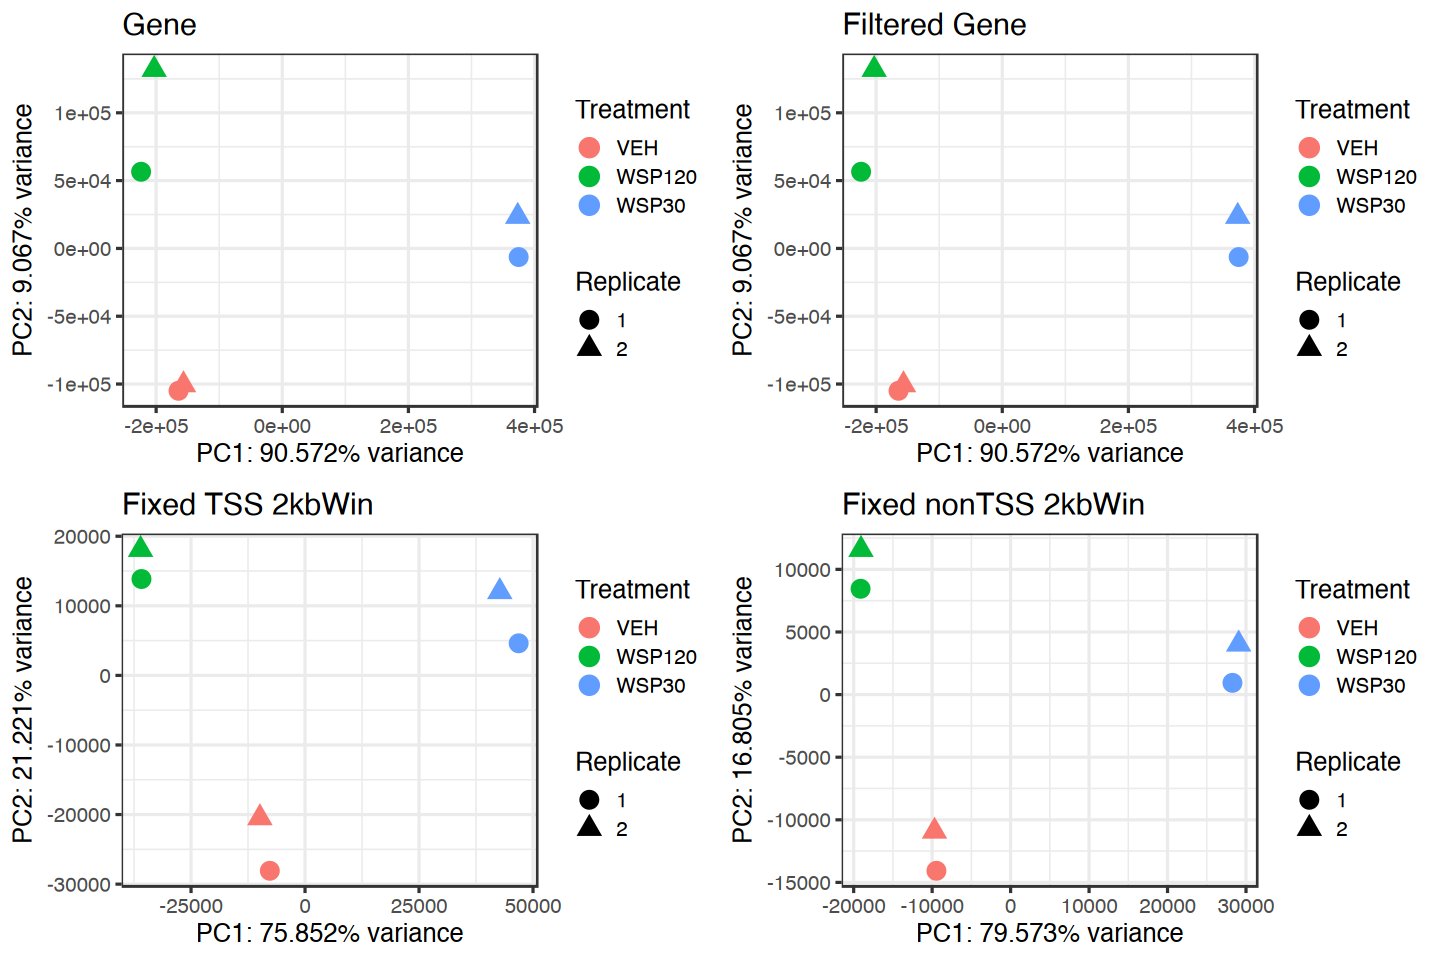

In [94]:
## Some functions for initial comparison to assess batch effects
plotPCA_hope_meta <- function(counts, metadata, ntop=500, Treat=TRUE) {
    rv <- rowVars(counts)
    length(rv) == nrow(counts)
    select <- order(rv, decreasing = TRUE)[seq_len(min(ntop,  length(rv)))]
    pca <- prcomp(t(counts[select, ]))
      percentVar <- pca$sdev^2/sum(pca$sdev^2)
    if (Treat == TRUE) {
        ## Select the PCAs and percentVar that you like instead of 1 and 2
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], metadata)
    ggplot() + 
    geom_point(data=d, aes(x = PC1, y = PC2, color=Treatment, shape=Replicate), size = 5) + 
    xlab(paste0("PC1: ", round(percentVar[1] * 100, 3), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100, 3), "% variance")) + 
     theme_bw(base_size=15)
    } else {
        ## Select the PCAs and percentVar that you like instead of 1 and 2
  d <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], metadata)
    ggplot() + 
    geom_point(data=d, aes(x = PC1, y = PC2, color=Replicate), size = 5) + 
    xlab(paste0("PC1: ", round(percentVar[1] * 100, 3), "% variance")) + 
    ylab(paste0("PC2: ", round(percentVar[2] * 100, 3), "% variance")) + 
     theme_bw(base_size=15)
    }
  
}

p4 <- plotPCA_hope_meta(gene_counts, metadata=design, ntop=500) + ggtitle(paste0("Gene"))
p5 <- plotPCA_hope_meta(gene_filt_counts, metadata=design, ntop=500) + ggtitle(paste0("Filtered Gene"))
p6 <- plotPCA_hope_meta(tss_win_counts_filt, metadata=design, ntop=500) + ggtitle(paste0("Fixed TSS 2kbWin"))
p7 <- plotPCA_hope_meta(nontss_win_counts_filt, metadata=design, ntop=500) + ggtitle(paste0("Fixed nonTSS 2kbWin"))
options(repr.plot.height = 8, repr.plot.width = 12)
plot_grid(p4, p5, p6, p7, nrow=2)

## 2. Run DESeq2

In [12]:
# get the DESeq objects
## NOT FILTERED
dds_tss_win <- DESeqDataSetFromMatrix(countData = tss_win_counts, colData = design, design = ~ Treatment)
dds_nontss_win <- DESeqDataSetFromMatrix(countData = nontss_win_counts, colData = design, design = ~ Treatment)
dds_gene <- DESeqDataSetFromMatrix(countData = gene_counts, colData = design, design = ~ Treatment)

## FILTERED
dds_gene_filt <- DESeqDataSetFromMatrix(countData = gene_filt_counts, colData = design, design = ~ Treatment)
dds_tss_win_filt <- DESeqDataSetFromMatrix(countData = tss_win_counts_filt, colData = design, design = ~ Treatment)
dds_nontss_win_filt <- DESeqDataSetFromMatrix(countData = nontss_win_counts_filt, colData = design, design = ~ Treatment)

dss_hk <- DESeqDataSetFromMatrix(countData = gene_hk_counts, colData = design, design = ~ Treatment)


In [13]:
# make clear that reference is Vehicle
dds_tss_win$Treatment <- relevel(dds_tss_win$Treatment, ref = "VEH")
dds_nontss_win$Treatment <- relevel(dds_nontss_win$Treatment, ref = "VEH")
dds_gene$Treatment <- relevel(dds_gene$Treatment, ref = "VEH")

dds_tss_win_filt$Treatment <- relevel(dds_tss_win_filt$Treatment, ref = "VEH")
dds_nontss_win_filt$Treatment <- relevel(dds_nontss_win_filt$Treatment, ref = "VEH")
dds_gene_filt$Treatment <- relevel(dds_gene_filt$Treatment, ref = "VEH")

dss_hk$Treatment <- relevel(dss_hk$Treatment, ref="VEH")

### 2A. Size Factors

[1] 133

[1] 132

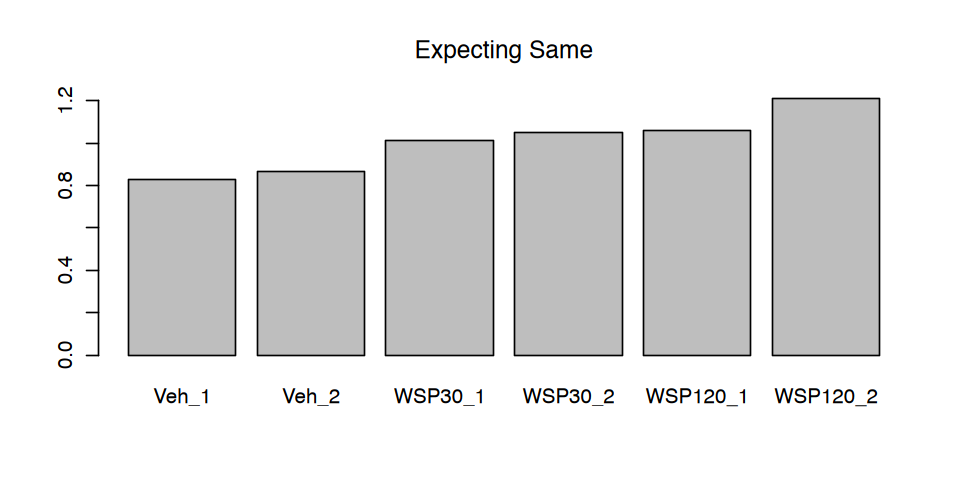

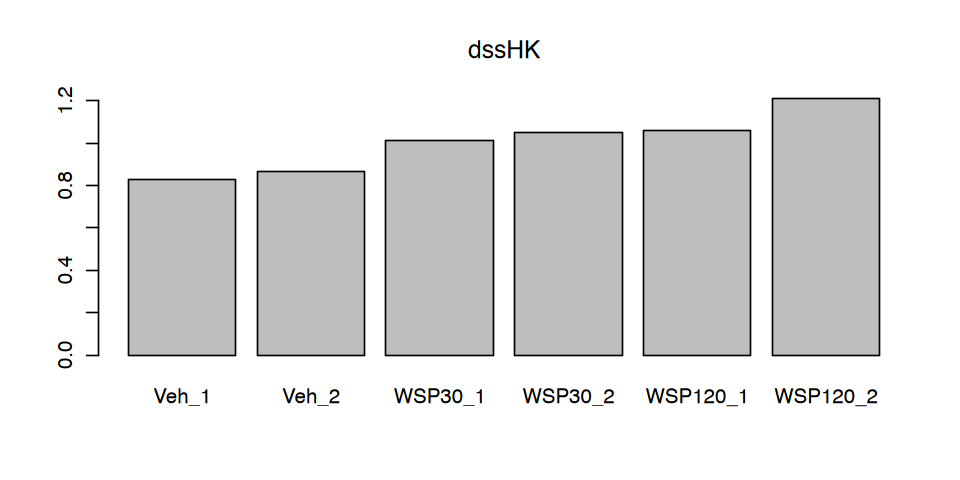

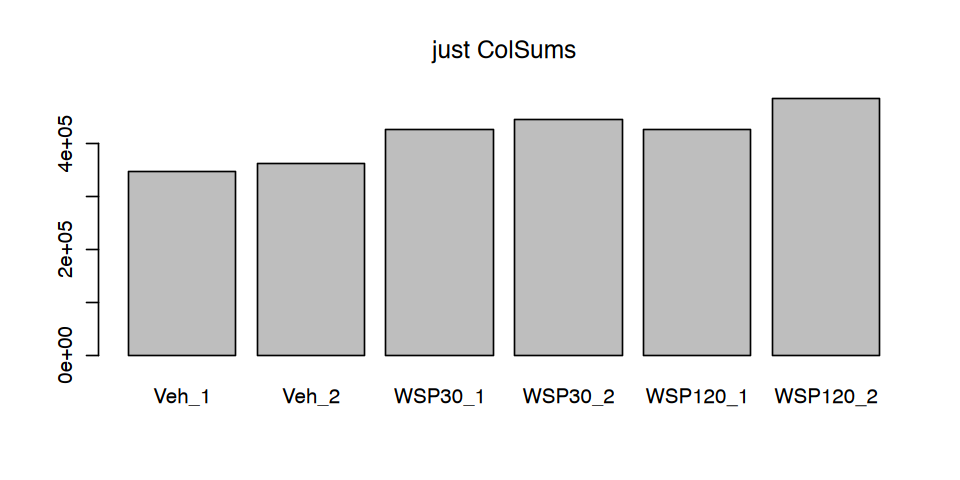

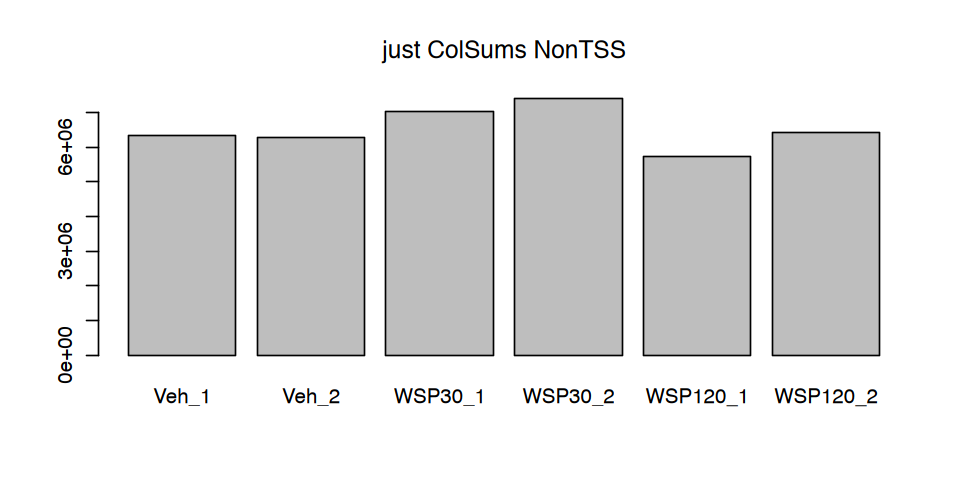

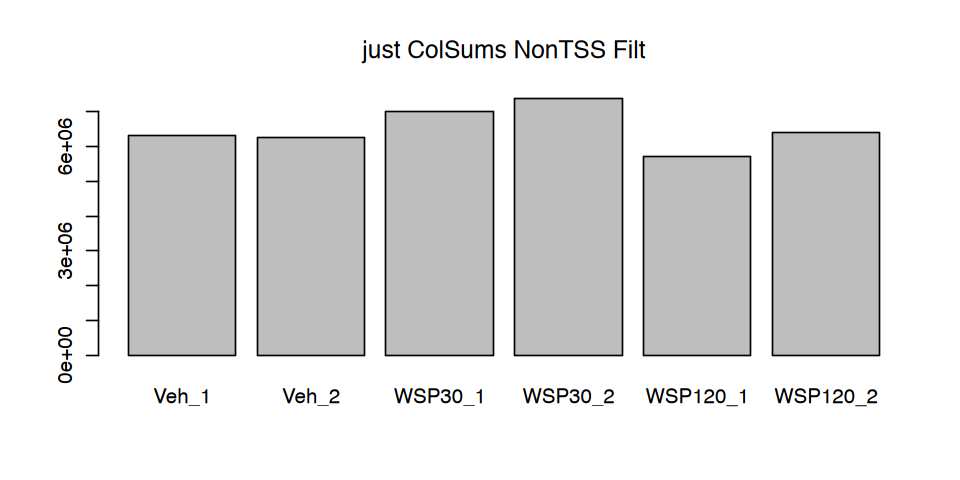

In [14]:
## Ratio
# get just the genes for normalization
isControl <- which(rownames(dds_gene_filt) %in% hk_genes)
length(hk_genes)
length(intersect(rownames(dds_gene_filt), hk_genes))
dds_gene_test = estimateSizeFactors(dds_gene_filt, controlGenes=isControl)
dds_gene_test2 = estimateSizeFactors(dss_hk)
dds_nontss_test = estimateSizeFactors(dds_nontss_win)
# test to see how different it would be without the control genes
options(repr.plot.height=4, repr.plot.width=8)
barplot(sizeFactors(dds_gene_test), main="Expecting Same")
barplot(sizeFactors(dds_gene_test2), main="dssHK")
barplot(colSums(gene_hk_counts), main="just ColSums")
barplot(colSums(nontss_win_counts), main="just ColSums NonTSS")
barplot(colSums(nontss_win_counts_filt), main="just ColSums NonTSS Filt")

In [15]:
sfs <- sizeFactors(dds_gene_test)
sizeFactors(dds_tss_win) <- sfs
sizeFactors(dds_tss_win_filt) <- sfs
sizeFactors(dds_nontss_win) <- sfs
sizeFactors(dds_nontss_win_filt) <- sfs
sizeFactors(dds_gene) <- sfs
sizeFactors(dds_gene_filt) <- sfs

using ntop=500 top features by variance

using ntop=500 top features by variance

using ntop=500 top features by variance



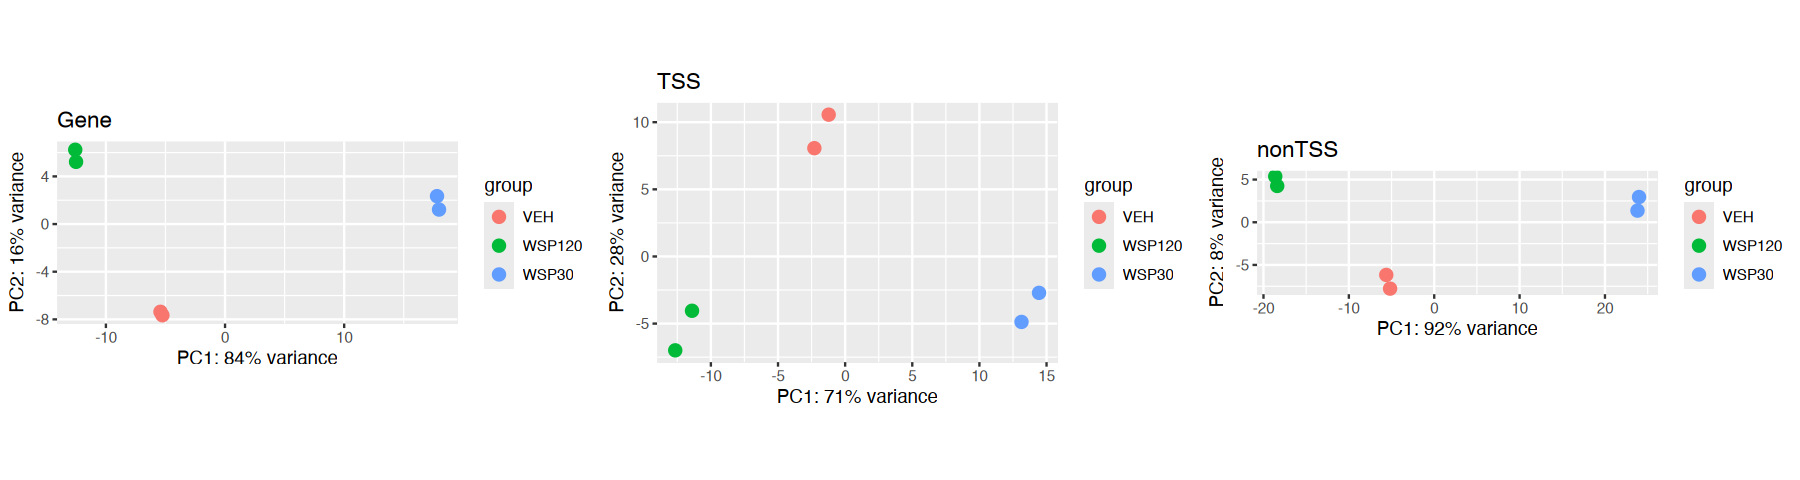

In [99]:
# plot PCA with with DESeq2 size factors
options(repr.plot.width=15, repr.plot.height=4)
# Ratio
vsd1 <- vst(dds_gene, blind = FALSE, fitType='local')
vsd3 <- vst(dds_tss_win, blind = FALSE, fitType='local')
vsd4 <- vst(dds_nontss_win, blind = FALSE, fitType='local')
p1 <- plotPCA(vsd1, intgroup = "Treatment") + ggtitle(paste0("Gene"))
p3 <- plotPCA(vsd3, intgroup = "Treatment") + ggtitle(paste0("TSS"))
p4 <- plotPCA(vsd4, intgroup = "Treatment") + ggtitle(paste0("nonTSS"))
plot_grid(p1, p3, p4, nrow=1)

In [16]:
#save normalized counts
count_df = as.data.frame(counts(dds_gene, normalized=TRUE))
count_df$Gene <- rownames(count_df)
count_df[1:2,]
write.table(count_df, "../results/DESeq2/WSP_normalized_counts.txt", 
           row.names=FALSE, quote=FALSE)
rm(count_df)
gc()

count_df = as.data.frame(counts(dds_nontss_win, normalized=TRUE))
count_df$Gene <- rownames(count_df)
count_df[1:2,]
write.table(count_df, "../results/DESeq2/WSP_nontss_normalized_counts.txt", 
           row.names=FALSE, quote=FALSE)
rm(count_df)
gc()

,Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
PLK1,3850.338,4054.513,2363.610,2347.456,3541.10,3308.52,PLK1
COP1,8158.620,7672.226,7631.873,7651.813,11116.92,12218.49,COP1


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,6793731,362.9,12159631,649.4,NA,12159631,649.4
Vcells,14948478,114.1,27906984,213.0,16384,23189154,177.0


,Veh_1,Veh_2,WSP30_1,WSP30_2,WSP120_1,WSP120_2,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
chr1:785582-786076,16.87159,21.897596,24.68264,30.42470,59.34804,56.97226,chr1:785582-786076
chr1:805310-805780,18.07671,8.067535,19.74611,18.06467,21.66675,34.67877,chr1:805310-805780


,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,6793741,362.9,12159631,649.4,NA,12159631,649.4
Vcells,14942214,114.1,27906984,213.0,16384,23189154,177.0


### 2B. Estimate Dispersions & Run Signfiicance Tests

In [100]:
## Ratio Normalization (parameteric is default)
dds_gene = estimateDispersions(dds_gene, fitType="parametric")
dds_tss_win = estimateDispersions(dds_tss_win, fitType="parametric")
dds_nontss_win = estimateDispersions(dds_nontss_win, fitType="parametric") 

dds_gene_filt = estimateDispersions(dds_gene_filt, fitType="parametric")
dds_tss_win_filt = estimateDispersions(dds_tss_win_filt, fitType="parametric")
dds_nontss_win_filt = estimateDispersions(dds_nontss_win_filt, fitType="parametric") 

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



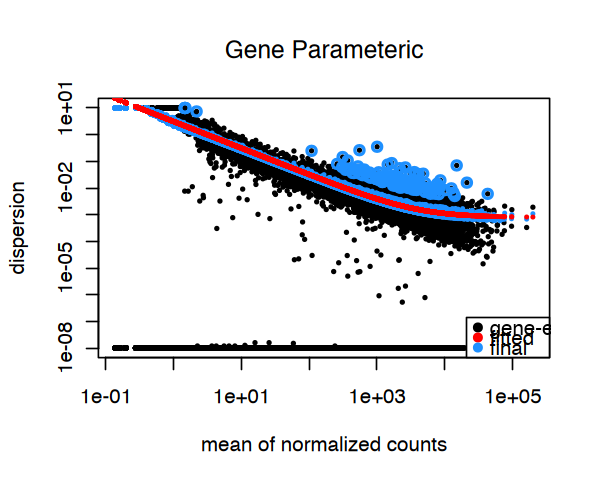

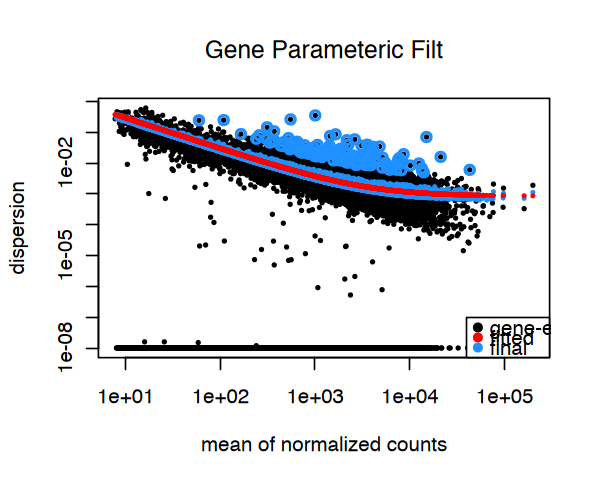

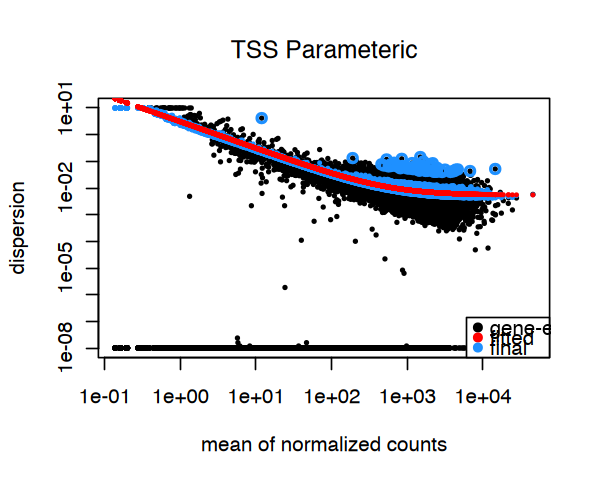

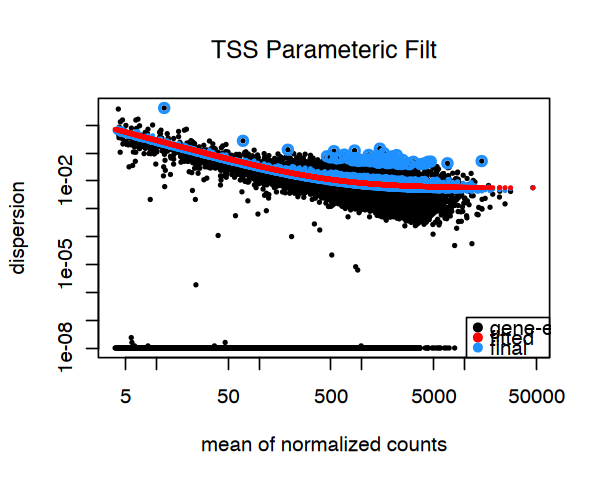

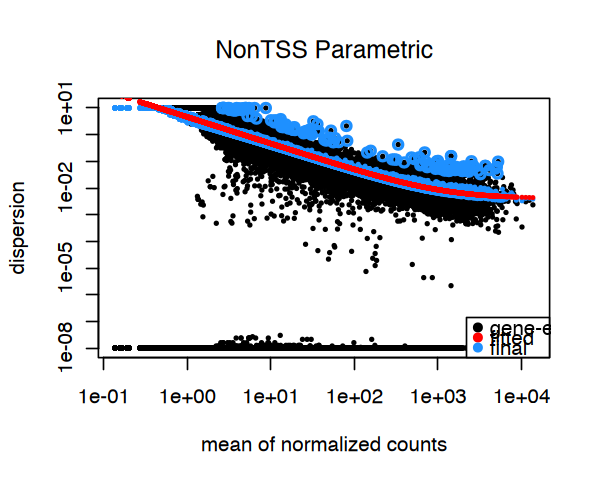

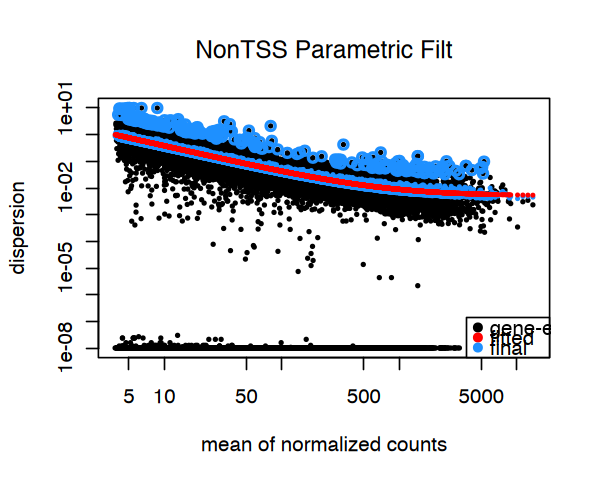

In [101]:
options(repr.plot.height=4, repr.plot.width=5)
plotDispEsts(dds_gene, main= "Gene Parameteric")
plotDispEsts(dds_gene_filt, main= "Gene Parameteric Filt")
plotDispEsts(dds_tss_win, main= "TSS Parameteric")
plotDispEsts(dds_tss_win_filt, main= "TSS Parameteric Filt")
plotDispEsts(dds_nontss_win, main= "NonTSS Parametric")
plotDispEsts(dds_nontss_win_filt, main= "NonTSS Parametric Filt")

In [102]:
dds_gene = nbinomWaldTest(dds_gene)
dds_tss_win = nbinomWaldTest(dds_tss_win)
dds_nontss_win = nbinomWaldTest(dds_nontss_win)

dds_gene_filt = nbinomWaldTest(dds_gene_filt)
dds_tss_win_filt = nbinomWaldTest(dds_tss_win_filt)
dds_nontss_win_filt = nbinomWaldTest(dds_nontss_win_filt)

### 2C. Get Results

In [103]:
binwidth_use=0.05
# Set your thresholds
padj_threshold <- 0.05
log2fc_threshold <- 0

In [104]:
# Get the significance comparisons ready
Up_Sig_genes = list("P120_vs_Veh"=c(), "P30_vs_Veh"=c(), "P120_vs_P30"=c())
Down_Sig_genes = list("P120_vs_Veh"=c(), "P30_vs_Veh"=c(), "P120_vs_P30"=c())
All_Sig_genes = list("P120_vs_Veh_up"=c(), "P30_vs_Veh_up"=c(), "P120_vs_P30_up"=c(), 
                     "P120_vs_Veh_down"=c(), "P30_vs_Veh_down"=c(), "P120_vs_P30_down"=c())
Up_Sig_nontss = list("P120_vs_Veh"=c(), "30_vs_Veh"=c(), "P120_vs_P30"=c())
Down_Sig_nontss = list("P120_vs_Veh"=c(), "30_vs_Veh"=c(), "P120_vs_P30"=c())
All_Sig_nontss = list("P120_vs_Veh_up"=c(), "30_vs_Veh_up"=c(), "P120_vs_P30_up"=c(), 
                     "P120_vs_Veh_down"=c(), "30_vs_Veh_down"=c(), "P120_vs_P30_down"=c())

In [105]:
gene_tss <- as.data.frame(fread("~/Downloads/assets//hg38_TSS1kb_refseq_diff53prime_with_putatives.bed"))
gene_tss[1:2,]
# only include the calls in the counts
gene_tss = gene_tss[gene_tss$V4 %in% kept_isoforms,]
gene_tss$Gene <- str_split_fixed(gene_tss$V4, ":", 2)[,1]
# get the tss
gene_tss$tss <- as.integer(as.integer(gene_tss$V2 + gene_tss$V3)/2)
# get the start and stop of tss for 3kb window
gene_tss$start = as.integer(gene_tss$tss - 1500)
gene_tss$stop = as.integer(gene_tss$tss + 1500)

,V1,V2,V3,V4,V5,V6
,<chr>,<int>,<int>,<chr>,<chr>,<chr>
1,chr1,11373,12373,DDX11L1:NR_046018.2,.,+
2,chr1,28870,29870,WASH7P:NR_024540.1,.,-


In [106]:
# function to get TFEA results
get_tfea_input_gene <- function(res, name, gene_tss) {
    # split by fold change (0 and positive)
    # rank by p-value (FC+ highest p-value to lowest)
    res <- as.data.frame(res)
    res[1:2,]
    old <- nrow(res)
    cat("\nNum orig & new", old, nrow(res))
    pos_FC <- res[res$log2FoldChange > 0,]
    neg_FC <- res[res$log2FoldChange < 0,]
    zero_FC <- res[res$log2FoldChange == 0,]
    # rank by p-value then FC
    pos_FC <- pos_FC %>%
      arrange(pvalue, desc(log2FoldChange))  # Sort by pval (ascending), then L2FC (descending)
    neg_FC <- neg_FC %>%
      arrange(desc(pvalue), desc(log2FoldChange)) # Sort by pval (descending), then L2FC (descending since most negative last)
    print(pos_FC[1:2,])
    print(neg_FC[1:2,])
    # recombine with any 0s in between
    pos_cutoff = nrow(pos_FC); neg_cutoff = nrow(neg_FC)
    if (nrow(zero_FC) != 0) {
        full_res = rbind(pos_FC, zero_FC, neg_FC)
        } else {
        full_res = rbind(pos_FC, neg_FC) }
    # print the position at which the separations take place
    cat("\n Positive rank end", nrow(pos_FC), "Negative rank end", nrow(full_res)-nrow(neg_FC), "Number zeros", nrow(zero_FC))
    set_used <- rownames(full_res)
    # now get the dataframe to save
    tfea_input <- data.frame("Name"=set_used)
    print(tfea_input[1:2,])
    # fc,p-value,rank
    tfea_input$fc_info <- paste0(2**(full_res$log2FoldChange), ",", full_res$pvalue, ",", paste0(seq(1, nrow(tfea_input))))
    # get the gene tss positions to line up
    filt_tss = gene_tss[gene_tss$Gene %in% set_used,]
    rownames(filt_tss) <- filt_tss$Gene
    filt_tss = filt_tss[set_used,]
    if (!identical(filt_tss$Gene, rownames(full_res))) {
        print(filt_tss[1:2,])
        print(full_res[1:2,])
        stop("Wrong order")}
    tfea_input$chrom = filt_tss$V1
    tfea_input$start = filt_tss$start
    tfea_input$stop = filt_tss$stop
    tfea_input$gene = filt_tss$Gene
    tfea_input = tfea_input[,c("chrom", "start", "stop", "fc_info", "gene")]
    colnames(tfea_input) <- c("#chrom", "start", "stop", "fc,p-value,rank", "gene")
    print(tfea_input[1:2,])
    write.table(tfea_input, 
                paste0(tfea_input_dir, name), 
                quote=FALSE, sep="\t", row.names=FALSE)
    }

[1] "WSP30 vs Veh"

out of 18613 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 3030, 16%
LFC < 0 (down)     : 8969, 48%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 8)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


Num orig & new 18613 18613      baseMean log2FoldChange      lfcSE     stat pvalue padj
EGR1 11261.886       5.421955 0.06020252 90.06192      0    0
CCN2  6357.192       3.626073 0.05950818 60.93404      0    0
           baseMean log2FoldChange      lfcSE          stat    pvalue      padj
ZNF516-DT  123.2781  -1.515302e-04 0.25623717 -0.0005913671 0.9995282 0.9995819
COPS9     2223.9988  -6.568285e-05 0.07035288 -0.0009336200 0.9992551 0.9993625

 Positive rank end 5764 Negative rank end 5764 Number zeros 0[1] "EGR1" "CCN2"
  #chrom     start      stop      fc,p-value,rank gene
1   chr5 138463978 138466978  42.871726055098,0,1 EGR1
2   chr6 131949872 131952872 12.346869780

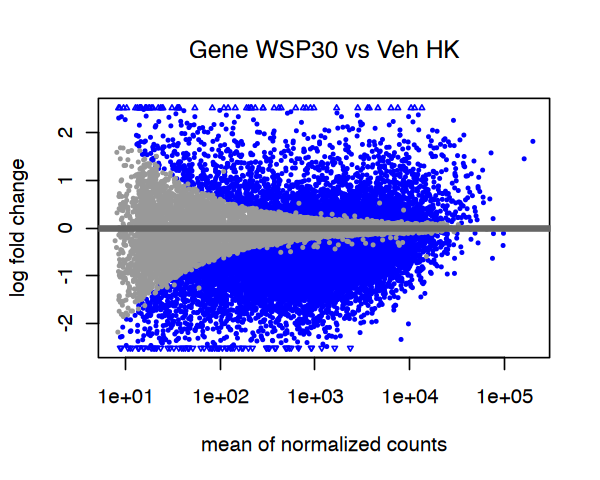

[1] 3030

[1] 8969

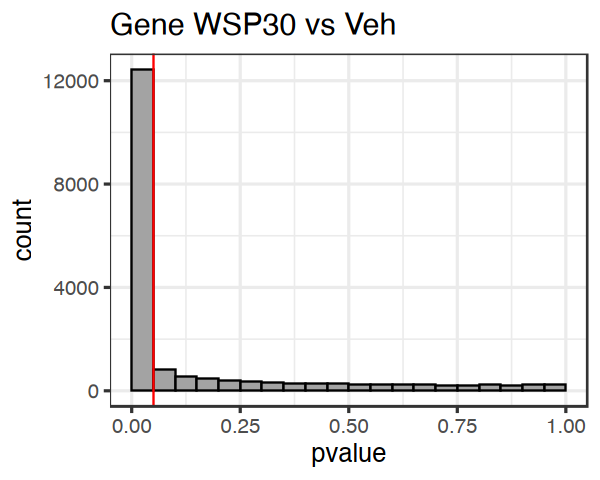

[1] "WSP120 vs Veh"

out of 18613 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 5126, 28%
LFC < 0 (down)     : 6474, 35%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 8)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


Num orig & new 18613 18613        baseMean log2FoldChange      lfcSE     stat        pvalue          padj
ITGBL1  8540.028       1.266031 0.05582917 22.67687 7.580011e-114 2.879321e-111
PLOD2  25573.956       1.177362 0.05637164 20.88572  7.221503e-97  1.948027e-94
          baseMean log2FoldChange     lfcSE         stat    pvalue      padj
MIR641    24.87905  -8.692723e-04 0.5856422 -0.001484306 0.9988157 0.9988694
SEPTIN2 8837.71732  -8.431799e-05 0.0458169 -0.001840325 0.9985316 0.9986389

 Positive rank end 8487 Negative rank end 8488 Number zeros 1[1] "ITGBL1" "PLOD2" 
  #chrom     start      stop                          fc,p-value,rank   gene
1  chr13 101451174 10145

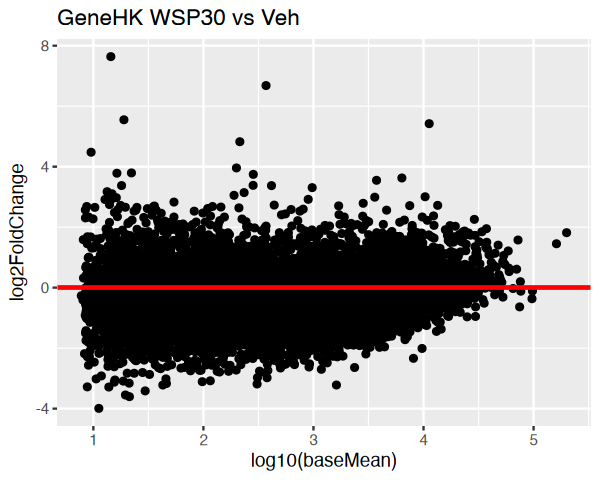

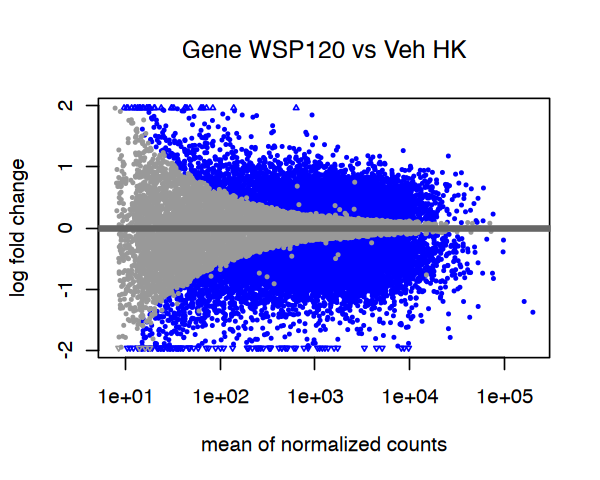

[1] 5126

[1] 6474

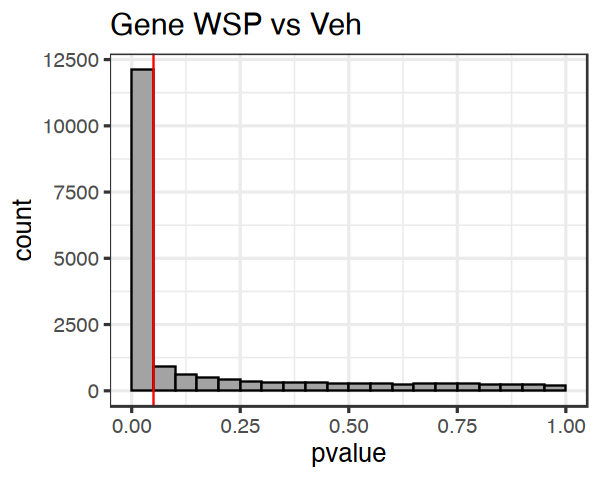

[1] "WSP120 vs WSP30"

out of 18613 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 8748, 47%
LFC < 0 (down)     : 3694, 20%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 8)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


Num orig & new 18613 18613       baseMean log2FoldChange     lfcSE     stat        pvalue          padj
SAMD11 1616.926       4.263967 0.1066372 39.98574  0.000000e+00  0.000000e+00
ID1    6512.082       1.602830 0.0560516 28.59561 7.619467e-180 7.624792e-178
       baseMean log2FoldChange     lfcSE          stat    pvalue      padj
UNC13D 99.79114  -0.0001156011 0.2774634 -0.0004166356 0.9996676 0.9997213
HOXB9  22.66441  -0.0002355980 0.5646772 -0.0004172260 0.9996671 0.9997213

 Positive rank end 12233 Negative rank end 12233 Number zeros 0[1] "SAMD11" "ID1"   
  #chrom    start     stop                         fc,p-value,rank   gene
1   chr1   924230   927230         

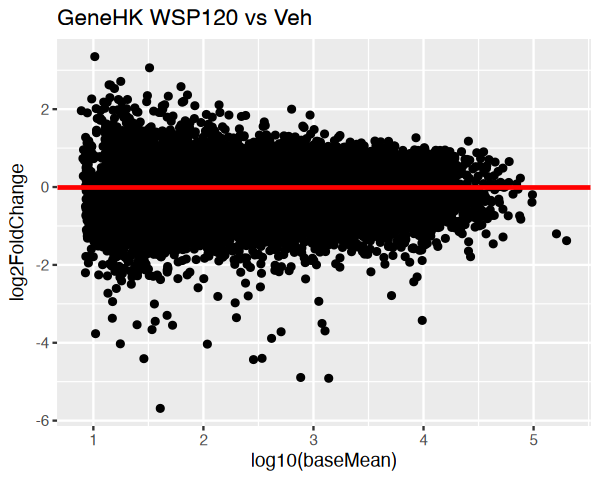

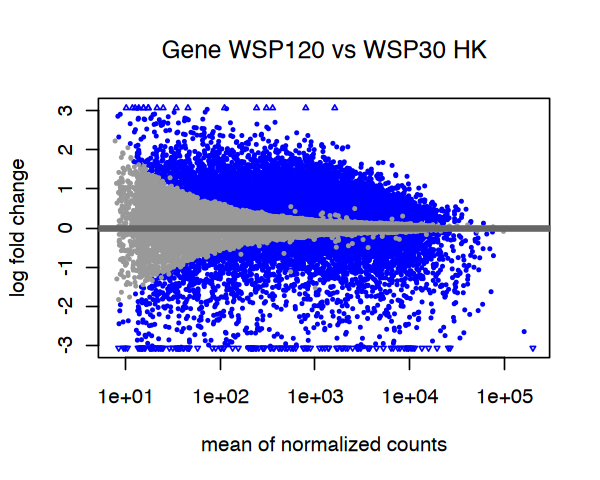

[1] 8748

[1] 3694

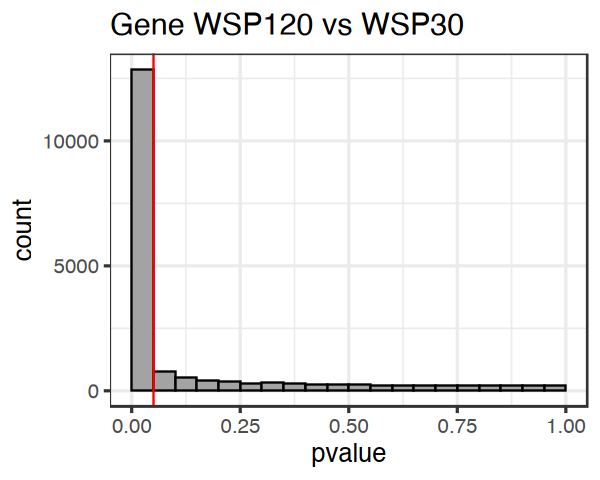

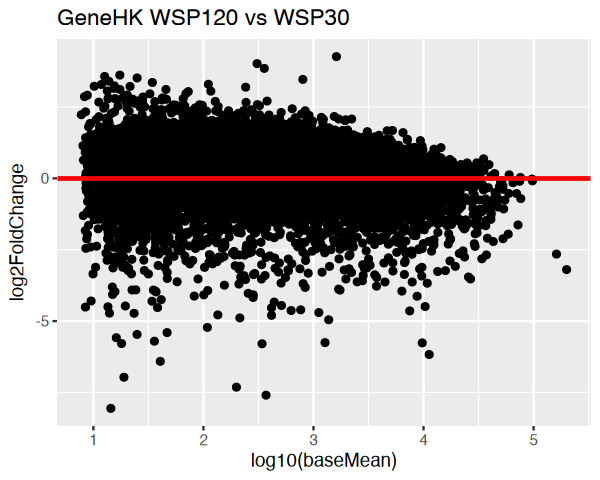

In [109]:
# Gene Results
print("WSP30 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP30", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
get_tfea_input_gene(gene_res, "GeneTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed", gene_tss)
plotMA(gene_res, main="Gene WSP30 vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP30 vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P30_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P30_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P30_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P30_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("GeneHK WSP30 vs Veh")
write.table(gene_res, 
            paste0(results_dir, "res_Gene_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)

print("WSP120 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP120", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
get_tfea_input_gene(gene_res, "GeneTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed", gene_tss)
plotMA(gene_res, main="Gene WSP120 vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P120_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P120_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P120_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P120_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("GeneHK WSP120 vs Veh")
write.table(gene_res, 
            paste0(results_dir, "res_Gene_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)

print("WSP120 vs WSP30")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP120", "WSP30"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
get_tfea_input_gene(gene_res, "GeneTSS_WSP120_vs_WSP30_par_rat_Wd_GeneHK.bed", gene_tss)
plotMA(gene_res, main="Gene WSP120 vs WSP30 HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP120 vs WSP30")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P120_vs_P30"]] = up_sig_genes
All_Sig_genes[["P120_vs_P30_up"]] = up_sig_genes
Down_Sig_genes[["P120_vs_P30"]] = down_sig_genes
All_Sig_genes[["P120_vs_P30_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("GeneHK WSP120 vs WSP30")
write.table(gene_res, 
            paste0(results_dir, "res_Gene_WSP120_vs_WSP30_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)

In [110]:
# function to get TFEA results
get_tfea_input <- function(res, name) {
    # split by fold change (0 and positive)
    # rank by p-value (FC+ highest p-value to lowest)
    res <- as.data.frame(res)
    res[1:2,]
    old <- nrow(res)
    cat("\nNum orig & new", old, nrow(res))
    pos_FC <- res[res$log2FoldChange > 0,]
    neg_FC <- res[res$log2FoldChange < 0,]
    zero_FC <- res[res$log2FoldChange == 0,]
     # rank by p-value then FC
    pos_FC <- pos_FC %>%
      arrange(pvalue, desc(log2FoldChange))  # Sort by pval (ascending), then L2FC (descending)
    neg_FC <- neg_FC %>%
      arrange(desc(pvalue), desc(log2FoldChange)) # Sort by pval (descending), then L2FC (descending since most negative last)
    print(pos_FC[1:2,])
    print(neg_FC[1:2,])
    # recombine with any 0s in between
    pos_cutoff = nrow(pos_FC); neg_cutoff = nrow(neg_FC)
    if (nrow(zero_FC) != 0) {
        full_res = rbind(pos_FC, zero_FC, neg_FC)
        } else {
        full_res = rbind(pos_FC, neg_FC) }
    # print the position at which the separations take place
    cat("\n Positive rank end", nrow(pos_FC), "Negative rank end", nrow(full_res)-nrow(neg_FC), "Number zeros", nrow(zero_FC))
    set_used <- rownames(full_res)
    # now get the dataframe to save
    tfea_input <- data.frame(str_split_fixed(set_used, ":", 2))
    print(tfea_input[1:2,])
    # fc,p-value,rank
    tfea_input$fc_info <- paste0(2**(full_res$log2FoldChange), ",", full_res$pvalue, ",", paste0(seq(1, nrow(tfea_input))))
    colnames(tfea_input) <- c("#chrom", "start_stop", "fc,p-value,rank")
    tfea_input_points = str_split_fixed(tfea_input$start_stop, "-", 2)
    tfea_input$mu <- as.integer((as.numeric(tfea_input_points[,1]) + as.numeric(tfea_input_points[,2]))/2)
    tfea_input$start = tfea_input$mu - 1500
    tfea_input$stop = tfea_input$mu + 1500
    print(tfea_input[1:2,])
    write.table(tfea_input[,c("#chrom", "start", "stop", "fc,p-value,rank")], 
                paste0(tfea_input_dir, name), 
                quote=FALSE, sep="\t", row.names=FALSE)
    }

[1] "WSP30 vs Veh"

out of 33810 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 5319, 16%
LFC < 0 (down)     : 7083, 21%
outliers [1]       : 0, 0%
low counts [2]     : 1311, 3.9%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


Num orig & new 33810 33810                        baseMean log2FoldChange     lfcSE     stat
chr17:80859015-80859865 2288.855       2.482274 0.1116686 22.22894
chr5:399569-400251      6047.300       2.049077 0.0952707 21.50795
                               pvalue          padj
chr17:80859015-80859865 1.803280e-109 5.860478e-105
chr5:399569-400251      1.311859e-102  2.131705e-98
                         baseMean log2FoldChange     lfcSE          stat
chr22:28819272-28819904 74.607662  -0.0000583474 0.3589247 -0.0001625617
chr8:377062-377562       4.370255  -0.0002567597 1.3757845 -0.0001866279
                           pvalue      padj
chr22:28819272-28819904 0.999870

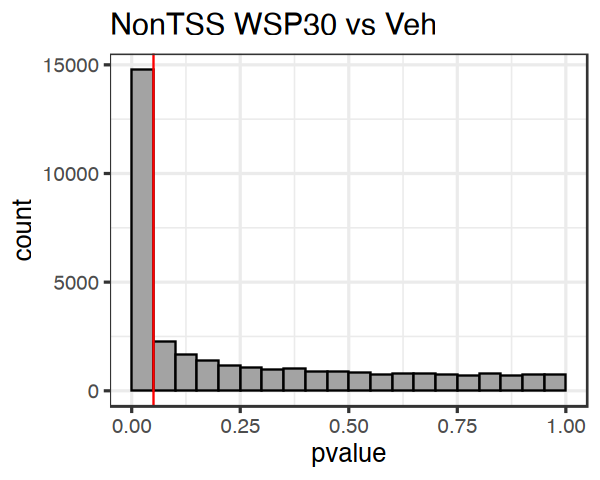

[1] 5319

[1] 7083

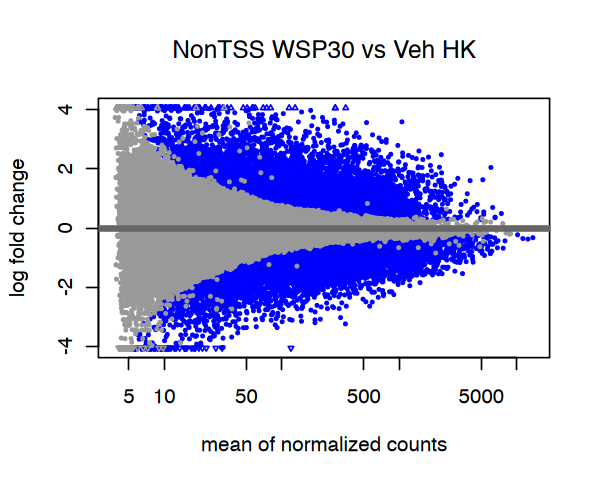

[1] "WSP120 vs Veh"

out of 33810 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 1515, 4.5%
LFC < 0 (down)     : 7403, 22%
outliers [1]       : 0, 0%
low counts [2]     : 7211, 21%
(mean count < 15)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


Num orig & new 33810 33810                         baseMean log2FoldChange     lfcSE     stat
chr6:26532917-26532965   982.4589       1.935161 0.1457693 13.27550
chr17:58631715-58632219 4604.9710       1.291230 0.1061623 12.16279
                              pvalue         padj
chr6:26532917-26532965  3.211300e-40 5.024551e-37
chr17:58631715-58632219 4.905162e-34 3.837423e-31
                        baseMean log2FoldChange     lfcSE          stat
chr2:99278744-99279230  22.42632  -1.483389e-06 0.6344608 -2.338032e-06
chr1:24018781-24019183 317.97771  -1.217385e-05 0.1795201 -6.781330e-05
                          pvalue      padj
chr2:99278744-99279230 0.9999981 0.99

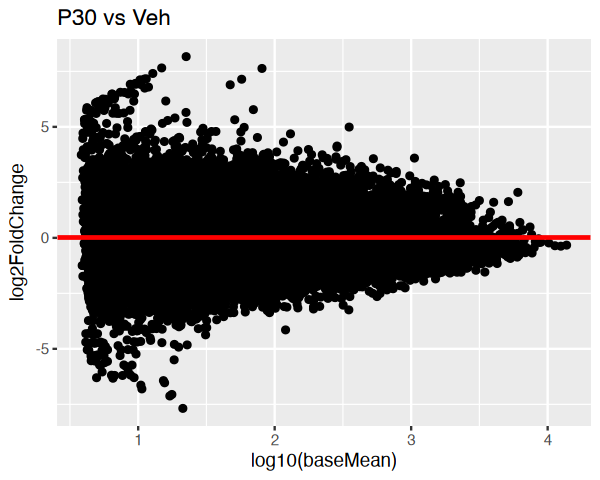

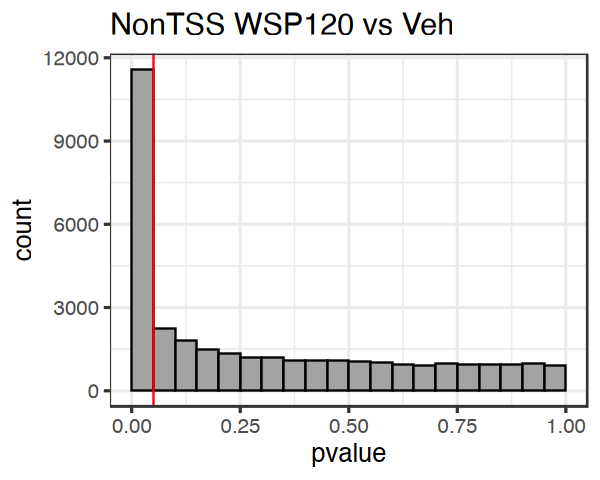

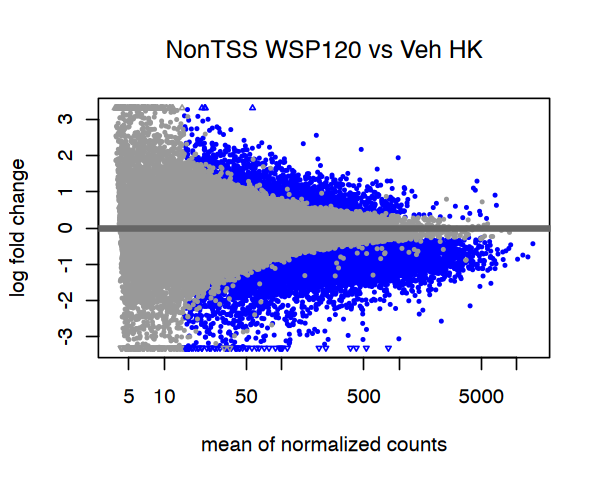

[1] "WSP120 vs WSP30"

out of 33810 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 5429, 16%
LFC < 0 (down)     : 8089, 24%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results


Num orig & new 33810 33810                       baseMean log2FoldChange     lfcSE     stat       pvalue
chr1:66271264-66271808 317.6728       4.368853 0.2537650 17.21614 2.009525e-66
chr1:66271819-66272253 349.4523       3.995385 0.2347335 17.02094 5.743644e-65
                               padj
chr1:66271264-66271808 3.538649e-64
chr1:66271819-66272253 9.381286e-63
                        baseMean log2FoldChange     lfcSE          stat
chr4:47531591-47532091  92.30739  -9.269647e-05 0.3301328 -0.0002807854
chr15:84525788-84526216 27.94509  -3.578622e-04 0.5978102 -0.0005986218
                           pvalue      padj
chr4:47531591-47532091  0.9997760 0.9998351
chr15

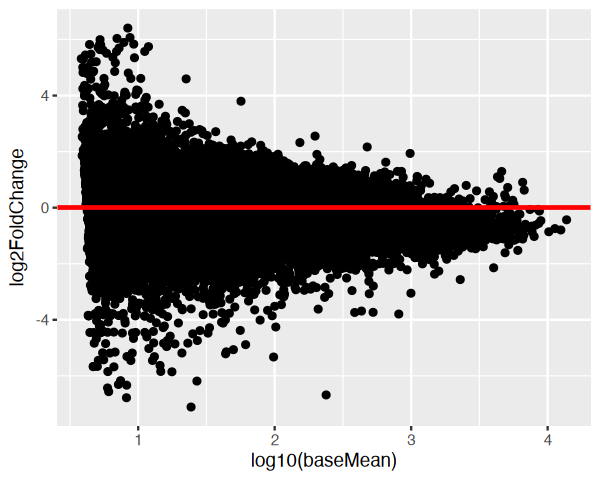

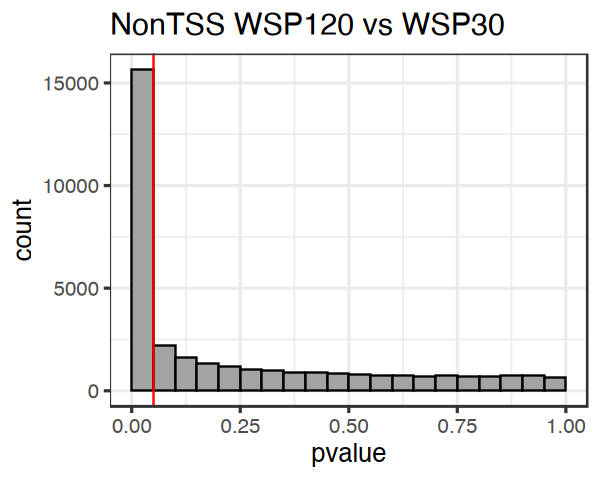

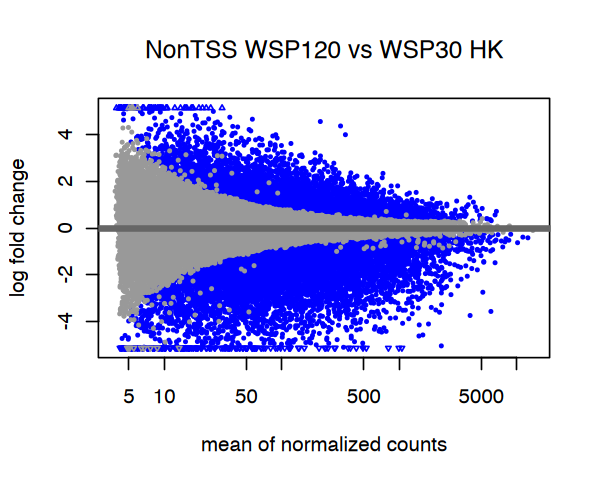

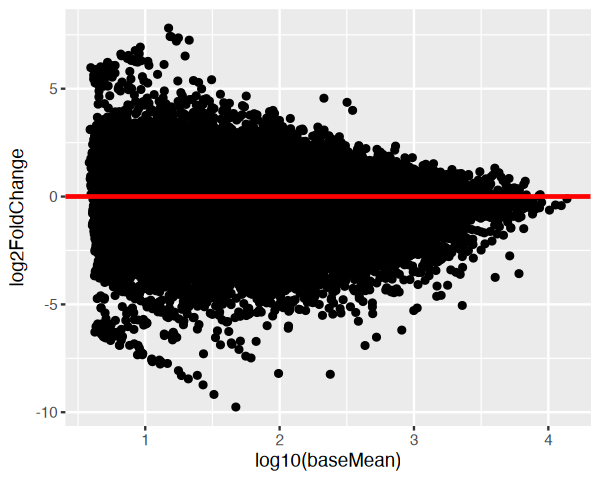

In [111]:
# NonTSS Results
options(repr.plot.height=4, repr.plot.width=5)
print("WSP30 vs Veh")
nontss_res = results(dds_nontss_win_filt, contrast= c("Treatment", "WSP30", "VEH"), alpha=0.05)
summary(nontss_res)
get_tfea_input(nontss_res, "NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed")
nontss_res <- nontss_res[order(nontss_res$pvalue),]

# plot pvalues
ggplot(data.frame(nontss_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=0.05, color="red") + ggtitle("NonTSS WSP30 vs Veh")
plotMA(nontss_res, main="NonTSS WSP30 vs Veh HK")
up_sig_nontss <- rownames(nontss_res[which(nontss_res$padj < padj_threshold & nontss_res$log2FoldChange > 0), ])
down_sig_nontss <- rownames(nontss_res[which(nontss_res$padj < padj_threshold & nontss_res$log2FoldChange < 0), ])
length(up_sig_nontss); length(down_sig_nontss)
Up_Sig_nontss[["P30_vs_Veh"]] = up_sig_nontss
All_Sig_nontss[["P30_vs_Veh_up"]] = up_sig_nontss
Down_Sig_nontss[["P30_vs_Veh"]] = down_sig_nontss
All_Sig_nontss[["P30_vs_Veh_down"]] = down_sig_nontss
testing = as.data.frame(nontss_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("P30 vs Veh")
write.table(nontss_res, 
            paste0(results_dir, "res_NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)

print("WSP120 vs Veh")
nontss_res = results(dds_nontss_win_filt, contrast= c("Treatment", "WSP120", "VEH"), alpha=0.05)
summary(nontss_res)
get_tfea_input(nontss_res, "NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed")
nontss_res <- nontss_res[order(nontss_res$pvalue),]
# plot pvalues
ggplot(data.frame(nontss_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=0.05, color="red") + ggtitle("NonTSS WSP120 vs Veh")
plotMA(nontss_res, main="NonTSS WSP120 vs Veh HK")
up_sig_nontss <- rownames(nontss_res[which(nontss_res$padj < padj_threshold & nontss_res$log2FoldChange > 0), ])
down_sig_nontss <- rownames(nontss_res[which(nontss_res$padj < padj_threshold & nontss_res$log2FoldChange < 0), ])

Up_Sig_nontss[["P120_vs_Veh"]] = up_sig_nontss
All_Sig_nontss[["P120_vs_Veh_up"]] = up_sig_nontss
Down_Sig_nontss[["P120_vs_Veh"]] = down_sig_nontss
All_Sig_nontss[["P120_vs_Veh_down"]] = down_sig_nontss
testing = as.data.frame(nontss_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1)
write.table(nontss_res, 
            paste0(results_dir, "res_NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.txt"), 
            sep=",", quote=FALSE)


print("WSP120 vs WSP30")
nontss_res = results(dds_nontss_win_filt, contrast= c("Treatment", "WSP120", "WSP30"), alpha=0.05)
summary(nontss_res)
get_tfea_input(nontss_res, "NonTSS_WSP120_vs_WSP30_par_rat_Wd_GeneHK.bed")
nontss_res <- nontss_res[order(nontss_res$pvalue),]
# plot pvalues
ggplot(data.frame(nontss_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=0.05, color="red") + ggtitle("NonTSS WSP120 vs WSP30")
plotMA(nontss_res, main="NonTSS WSP120 vs WSP30 HK")
up_sig_nontss <- rownames(nontss_res[which(nontss_res$padj < padj_threshold & nontss_res$log2FoldChange > 0), ])
down_sig_nontss <- rownames(nontss_res[which(nontss_res$padj < padj_threshold & nontss_res$log2FoldChange < 0), ])

Up_Sig_nontss[["P120_vs_P30"]] = up_sig_nontss
All_Sig_nontss[["P120_vs_P30_up"]] = up_sig_nontss
Down_Sig_nontss[["P120_vs_P30"]] = down_sig_nontss
All_Sig_nontss[["P120_vs_P30_down"]] = down_sig_nontss

testing = as.data.frame(nontss_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1)
write.table(nontss_res, 
            paste0(results_dir, "res_NonTSS_WSP120_vs_WSP30_par_rat_Wd_HK.txt"), 
            sep=",", quote=FALSE)


## 4. GO Analysis with Genes

In [30]:
run_go_analysis <- function(gene_symbols) {
    # gene_ids <- bitr(gene_symbols, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
    # # Extract the Entrez IDs
    # entrez_gene_list <- gene_ids$ENTREZID
    # GO enrichment analysis
    go_enrichment <- enrichGO(gene = gene_symbols,
                          OrgDb = org.Hs.eg.db,
                          keyType = "SYMBOL",
                          ont = "ALL",  # Can be "BP", "MF", or "CC" for specific ontology categories
                          pAdjustMethod = "BH",
                          pvalueCutoff = 0.05,
                          qvalueCutoff = 0.05)

    return(go_enrichment)
    }

In [31]:
## EARLY and Temporary
early_rise_genes = setdiff(intersect(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P120_vs_P30"]]), 
                           union(Up_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_Veh"]]))
length(early_rise_genes)
go_early_rise = run_go_analysis(early_rise_genes)
early_fall_genes = setdiff(intersect(Down_Sig_genes[["P30_vs_Veh"]], Up_Sig_genes[["P120_vs_P30"]]), 
                           union(Up_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_Veh"]]))
length(early_fall_genes)
go_early_fall = run_go_analysis(early_fall_genes)
go_early_both = run_go_analysis(union(early_rise_genes, early_fall_genes))

[1] 751

[1] 1891

In [32]:
## Early and stays (plateaus)
early_plat_up = setdiff(intersect(Up_Sig_genes[["P120_vs_Veh"]], Up_Sig_genes[["P30_vs_Veh"]]), 
                    union(Up_Sig_genes[["P120_vs_P30"]], Down_Sig_genes[["P120_vs_P30"]]))
length(early_plat_up)
go_early_plat_up = run_go_analysis(early_plat_up)
early_plat_down = setdiff(intersect(Down_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]), 
                    union(Up_Sig_genes[["P120_vs_P30"]], Down_Sig_genes[["P120_vs_P30"]]))
length(early_plat_down)
go_early_plat_down = run_go_analysis(early_plat_down)
go_early_plat_both = run_go_analysis(union(early_plat_up, early_plat_down))

[1] 894

[1] 959

In [33]:
## LATE
late_up = setdiff(intersect(Up_Sig_genes[["P120_vs_Veh"]], Up_Sig_genes[["P120_vs_P30"]]), 
                    union(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]))
length(late_up)
go_late_up = run_go_analysis(late_up)
late_down = setdiff(intersect(Down_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_P30"]]), 
                    union(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]))
length(late_down)
go_late_down = run_go_analysis(late_down)
go_late_both = run_go_analysis(union(late_up, late_down))

[1] 2521

[1] 633

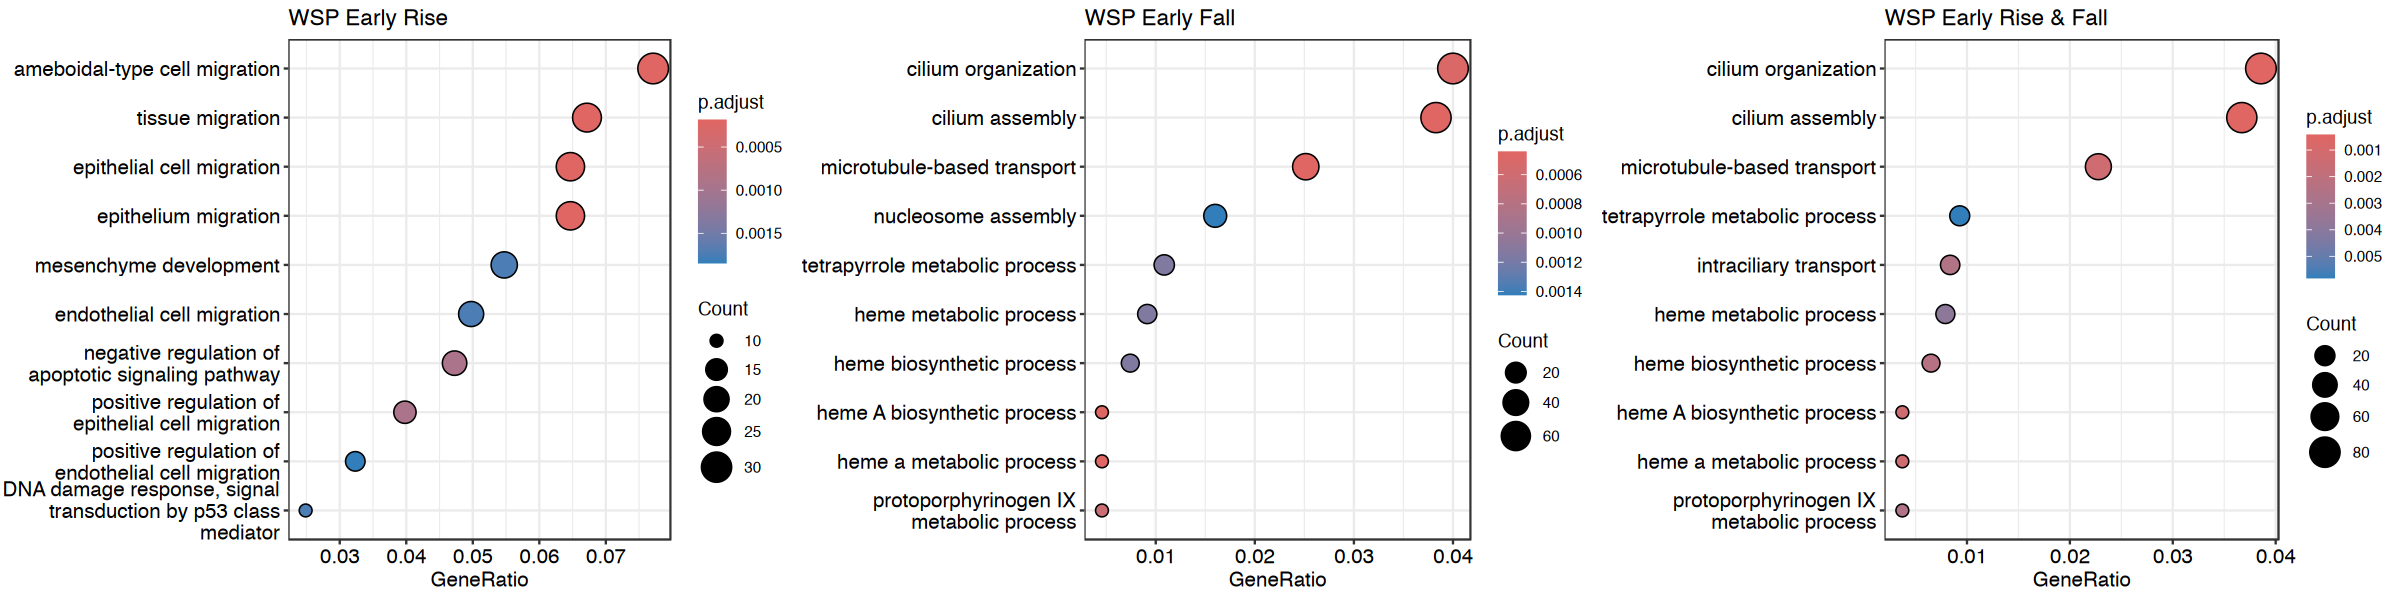

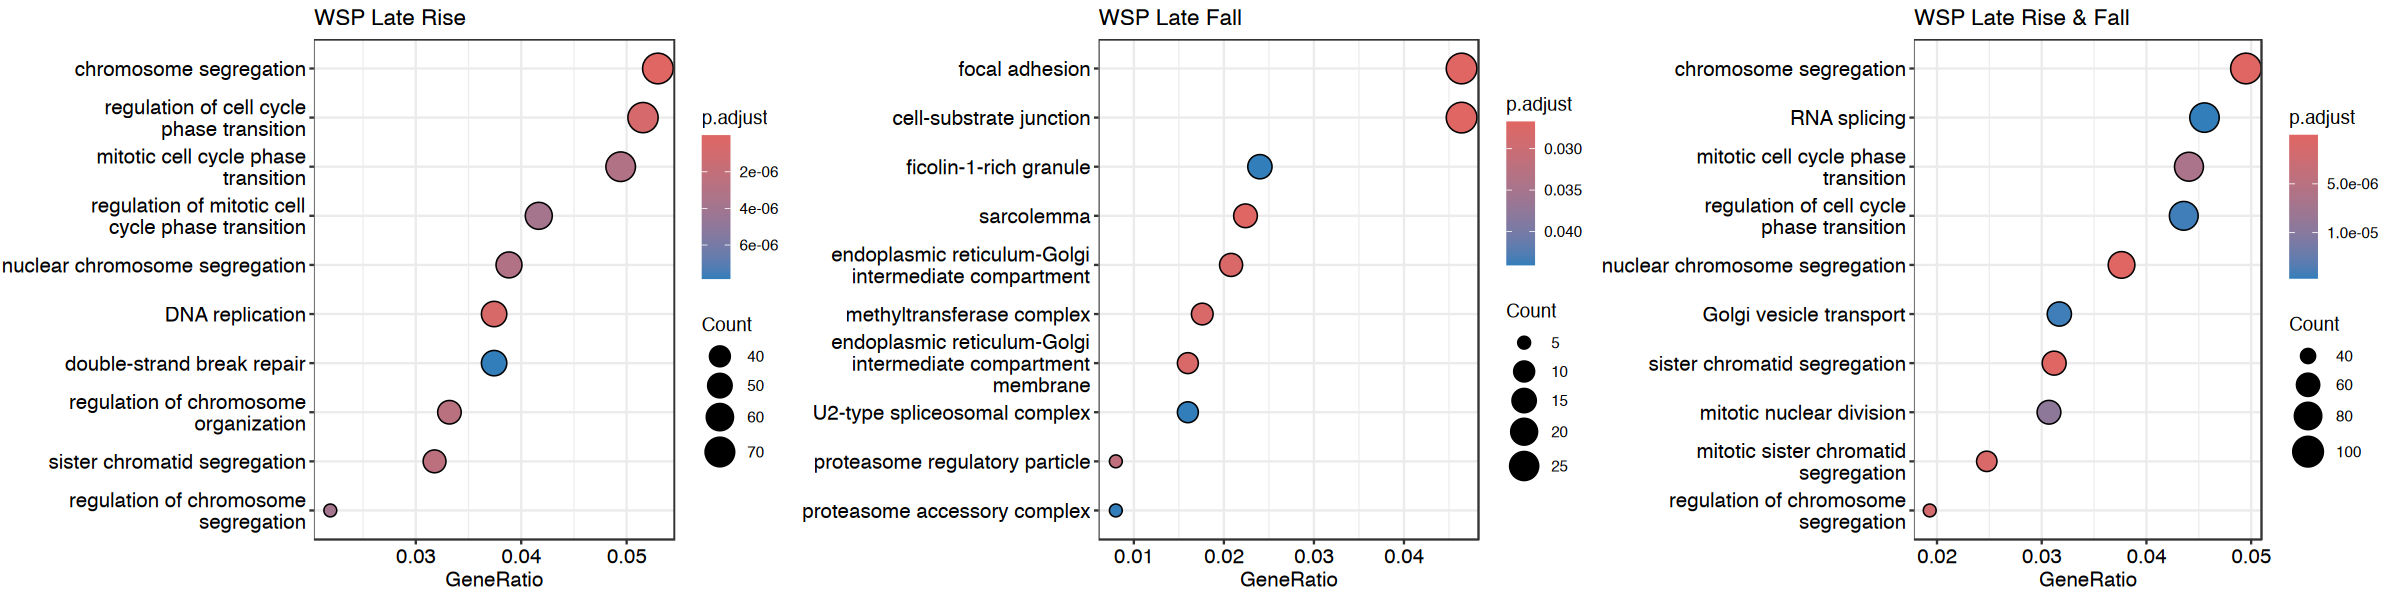

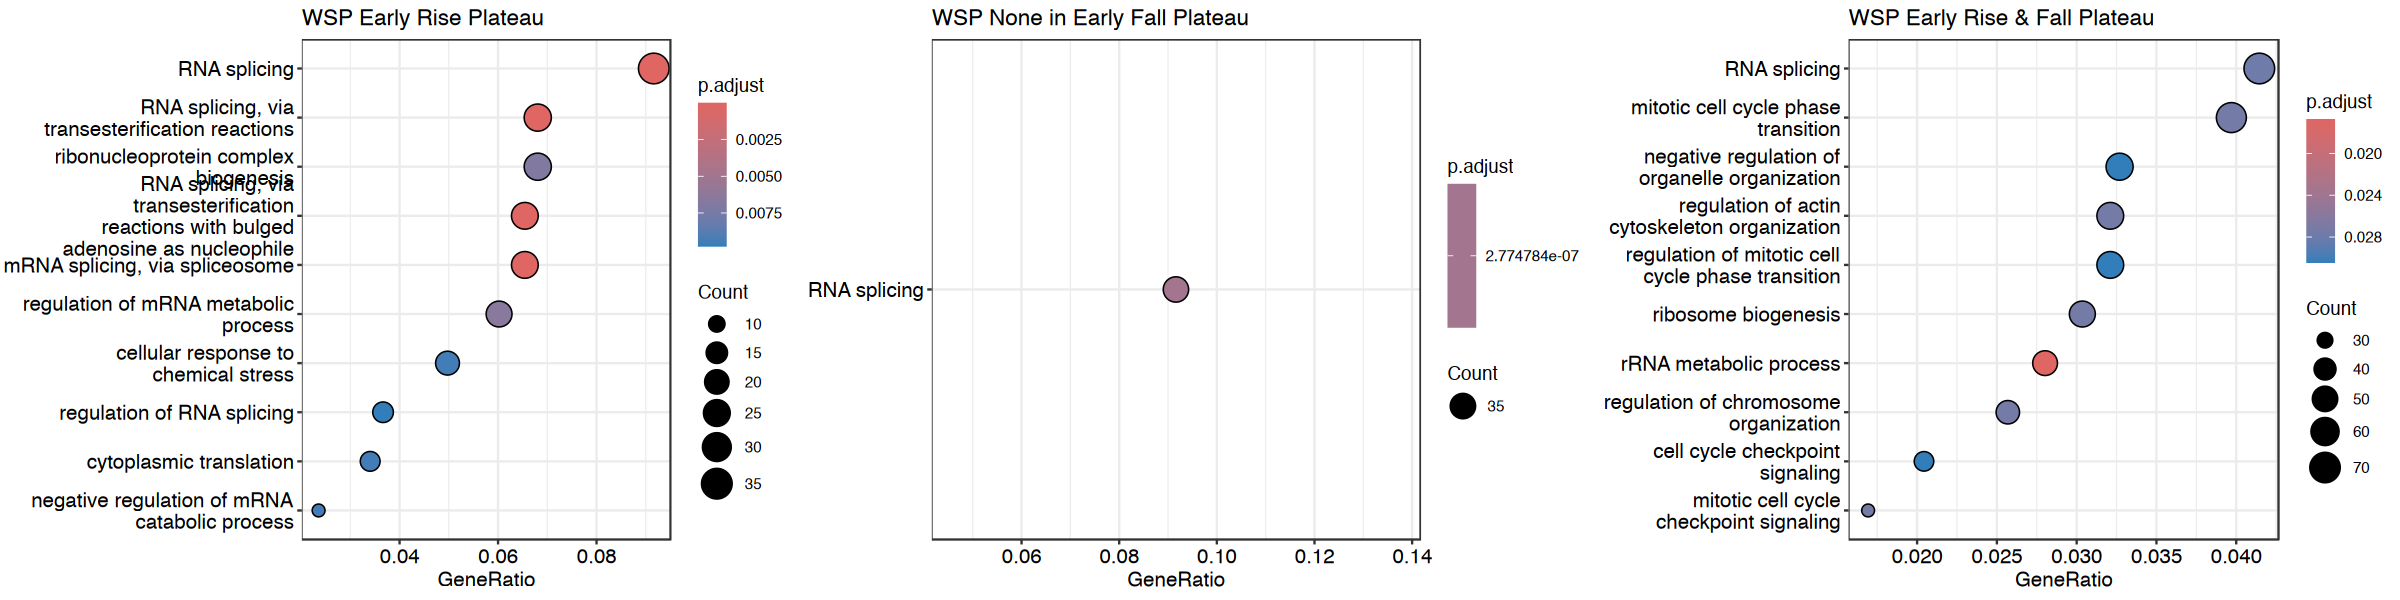

In [37]:
options(repr.plot.height=5, repr.plot.width=20)
pert="WSP"
p1 <- dotplot(go_early_rise, showCategory = 10, title=paste(pert,  "Early Rise"))
p2 <- dotplot(go_early_fall, showCategory = 10, title=paste(pert,  "Early Fall"))
p3 <- dotplot(go_early_both, showCategory = 10, title=paste(pert,  "Early Rise & Fall"))
grid.arrange(p1, p2, p3, ncol = 3)
# options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_late_up, showCategory = 10, title=paste(pert,  "Late Rise"))
p2 <- dotplot(go_late_down, showCategory = 10, title=paste(pert,  "Late Fall"))
p3 <- dotplot(go_late_both, showCategory = 10, title=paste(pert,  "Late Rise & Fall"))
grid.arrange(p1, p2, p3, ncol = 3)
options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_early_plat_up, showCategory = 10, title=paste(pert,  "Early Rise Plateau"))
p2 <- dotplot(go_early_plat_up, showCategory = 0, title=paste(pert,  "None in Early Fall Plateau"))
p3 <- dotplot(go_early_plat_both, showCategory = 10, title=paste(pert,  "Early Rise & Fall Plateau"))
grid.arrange(p1, p2, p3, ncol = 3)

### Again but with greater stringency for significance calls

[1] "WSP30 vs Veh"

out of 18613 with nonzero total read count
adjusted p-value < 0.001
LFC > 0 (up)       : 2135, 11%
LFC < 0 (down)     : 7050, 38%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 8)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



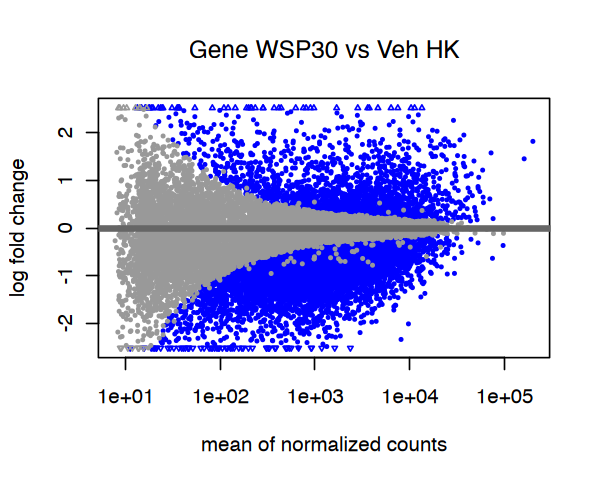

[1] 2135

[1] 7050

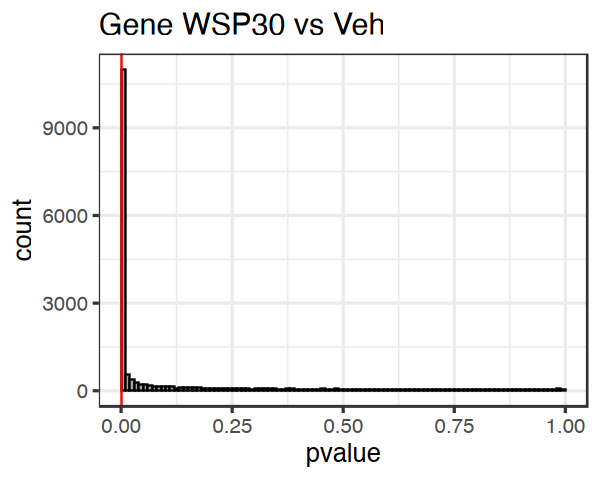

[1] "WSP120 vs Veh"

out of 18613 with nonzero total read count
adjusted p-value < 0.001
LFC > 0 (up)       : 3755, 20%
LFC < 0 (down)     : 4990, 27%
outliers [1]       : 0, 0%
low counts [2]     : 361, 1.9%
(mean count < 14)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



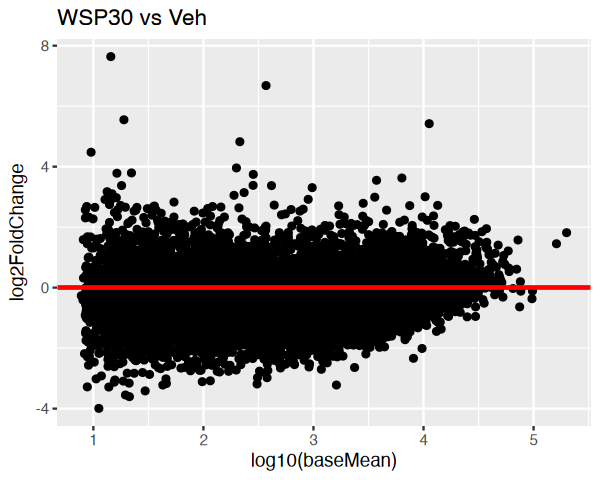

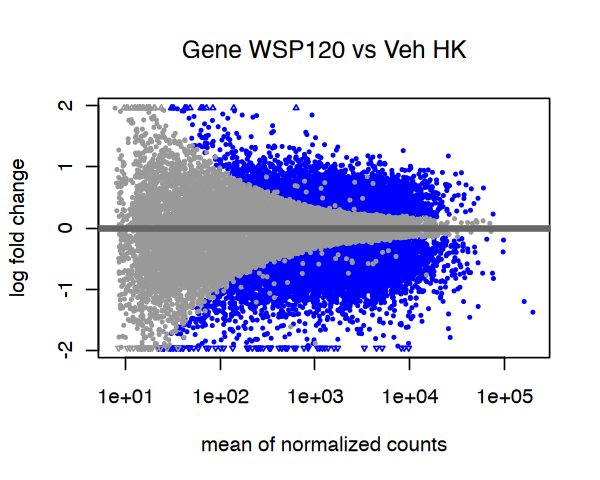

[1] 3755

[1] 4990

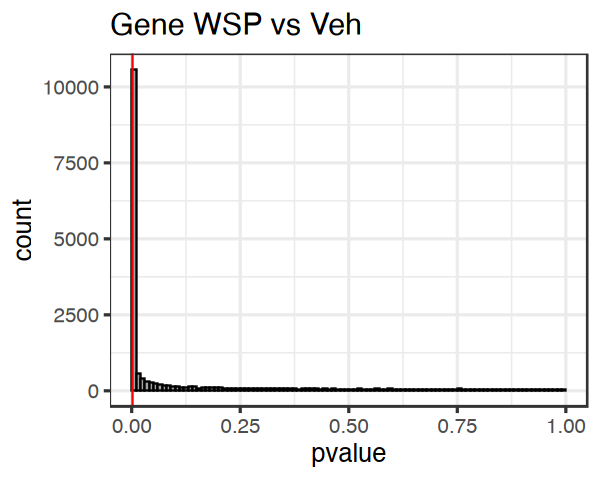

[1] "WSP120 vs WSP30"

out of 18613 with nonzero total read count
adjusted p-value < 0.001
LFC > 0 (up)       : 6965, 37%
LFC < 0 (down)     : 2717, 15%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 8)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



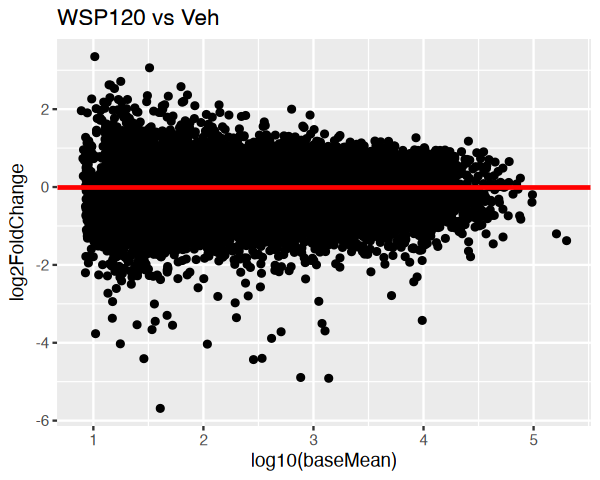

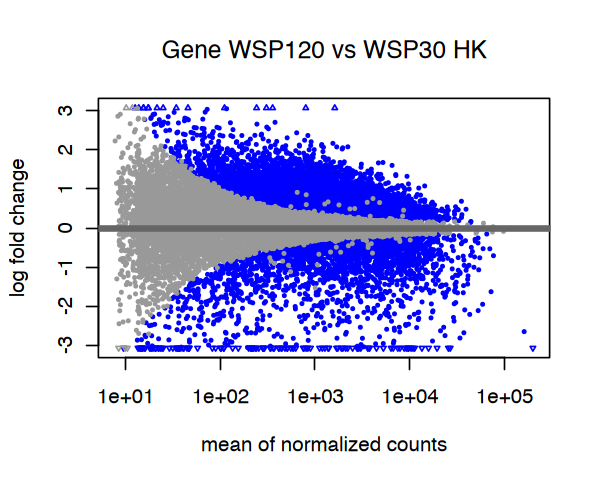

[1] 6965

[1] 2717

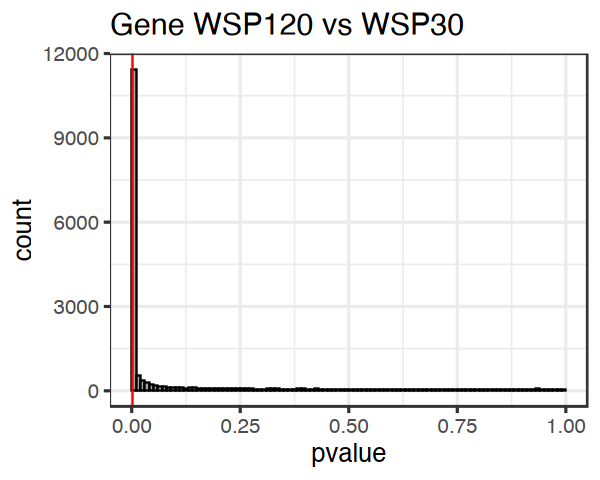

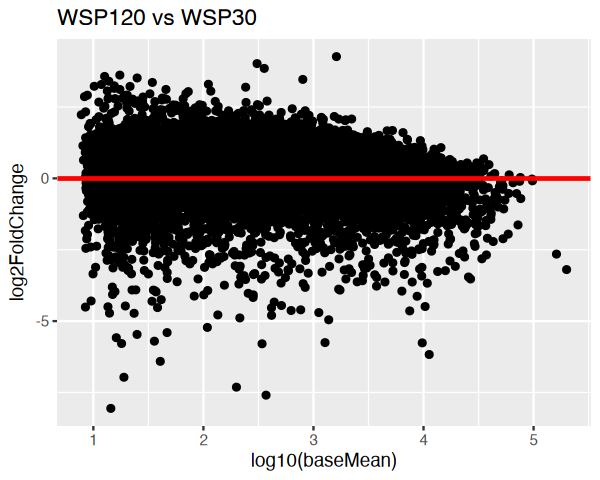

In [47]:
# Gene Results
padj_threshold=0.001
binwidth_use = 0.01
print("WSP30 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP30", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP30 vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP30 vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P30_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P30_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P30_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P30_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP30 vs Veh")


print("WSP120 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP120", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP120 vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P120_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P120_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P120_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P120_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP120 vs Veh")



print("WSP120 vs WSP30")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP120", "WSP30"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP120 vs WSP30 HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP120 vs WSP30")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P120_vs_P30"]] = up_sig_genes
All_Sig_genes[["P120_vs_P30_up"]] = up_sig_genes
Down_Sig_genes[["P120_vs_P30"]] = down_sig_genes
All_Sig_genes[["P120_vs_P30_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP120 vs WSP30")




In [38]:
## EARLY and Temporary
early_rise_genes = setdiff(intersect(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P120_vs_P30"]]), 
                           union(Up_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_Veh"]]))
length(early_rise_genes)
go_early_rise = run_go_analysis(early_rise_genes)
early_fall_genes = setdiff(intersect(Down_Sig_genes[["P30_vs_Veh"]], Up_Sig_genes[["P120_vs_P30"]]), 
                           union(Up_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_Veh"]]))
length(early_fall_genes)
go_early_fall = run_go_analysis(early_fall_genes)
go_early_both = run_go_analysis(union(early_rise_genes, early_fall_genes))

[1] 548

[1] 2316

In [32]:
## Early and stays (plateaus)
early_plat_up = setdiff(intersect(Up_Sig_genes[["P120_vs_Veh"]], Up_Sig_genes[["P30_vs_Veh"]]), 
                    union(Up_Sig_genes[["P120_vs_P30"]], Down_Sig_genes[["P120_vs_P30"]]))
length(early_plat_up)
go_early_plat_up = run_go_analysis(early_plat_up)
early_plat_down = setdiff(intersect(Down_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]), 
                    union(Up_Sig_genes[["P120_vs_P30"]], Down_Sig_genes[["P120_vs_P30"]]))
length(early_plat_down)
go_early_plat_down = run_go_analysis(early_plat_down)
go_early_plat_both = run_go_analysis(union(early_plat_up, early_plat_down))

[1] 450

[1] 1691

In [33]:
## LATE
late_up = setdiff(intersect(Up_Sig_genes[["P120_vs_Veh"]], Up_Sig_genes[["P120_vs_P30"]]), 
                    union(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]))
length(late_up)
go_late_up = run_go_analysis(late_up)
late_down = setdiff(intersect(Down_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_P30"]]), 
                    union(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]))
length(late_down)
go_late_down = run_go_analysis(late_down)
go_late_both = run_go_analysis(union(late_up, late_down))

[1] 1702

[1] 760

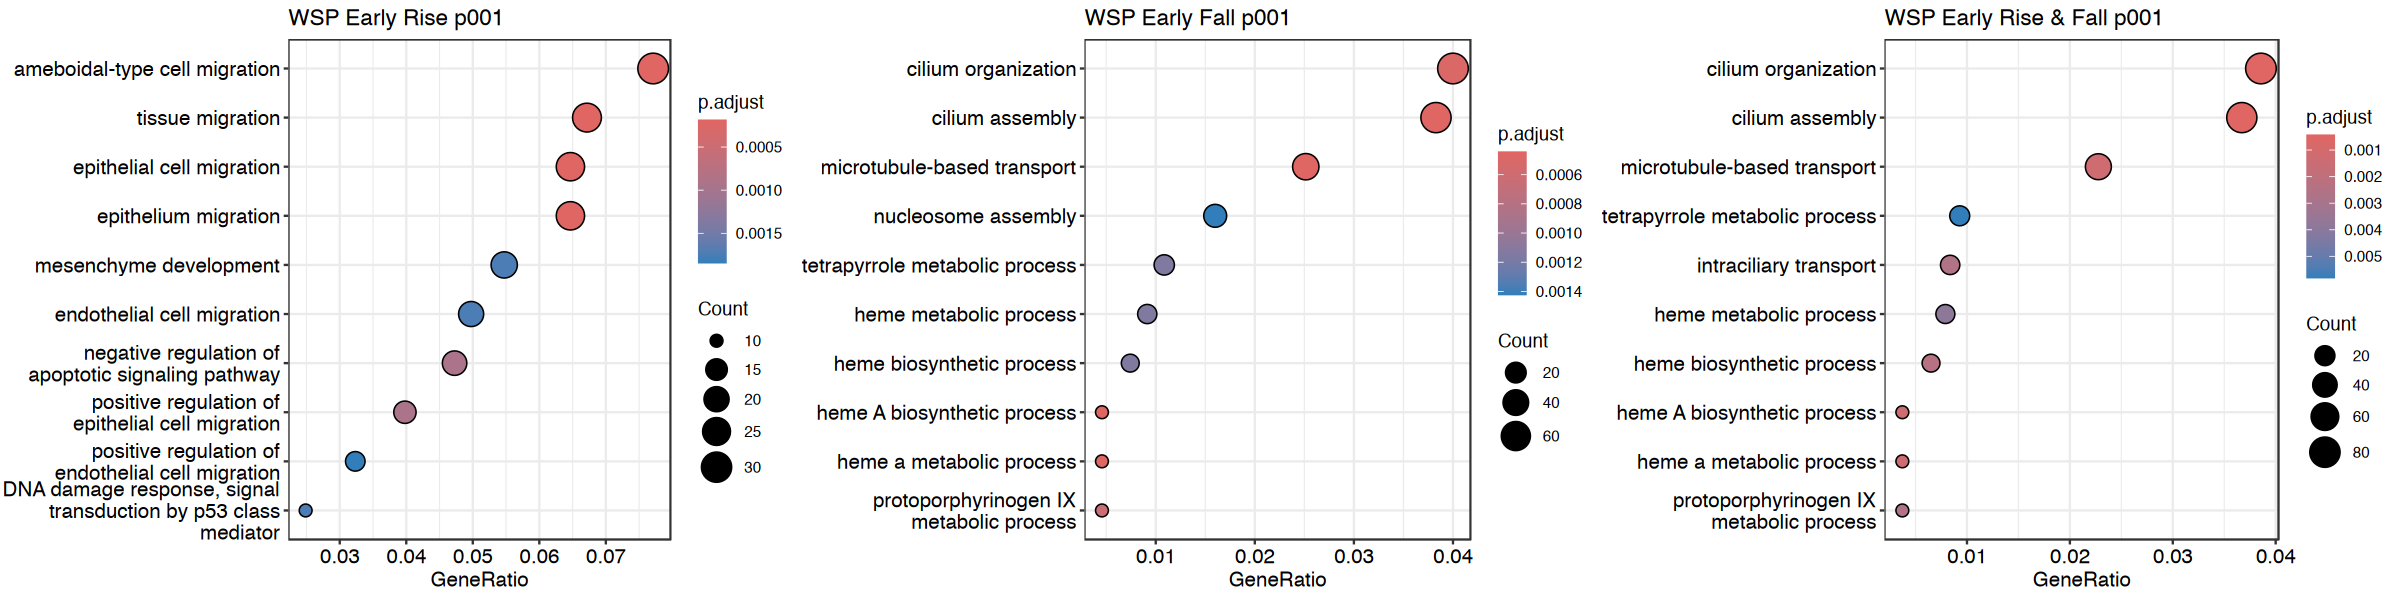

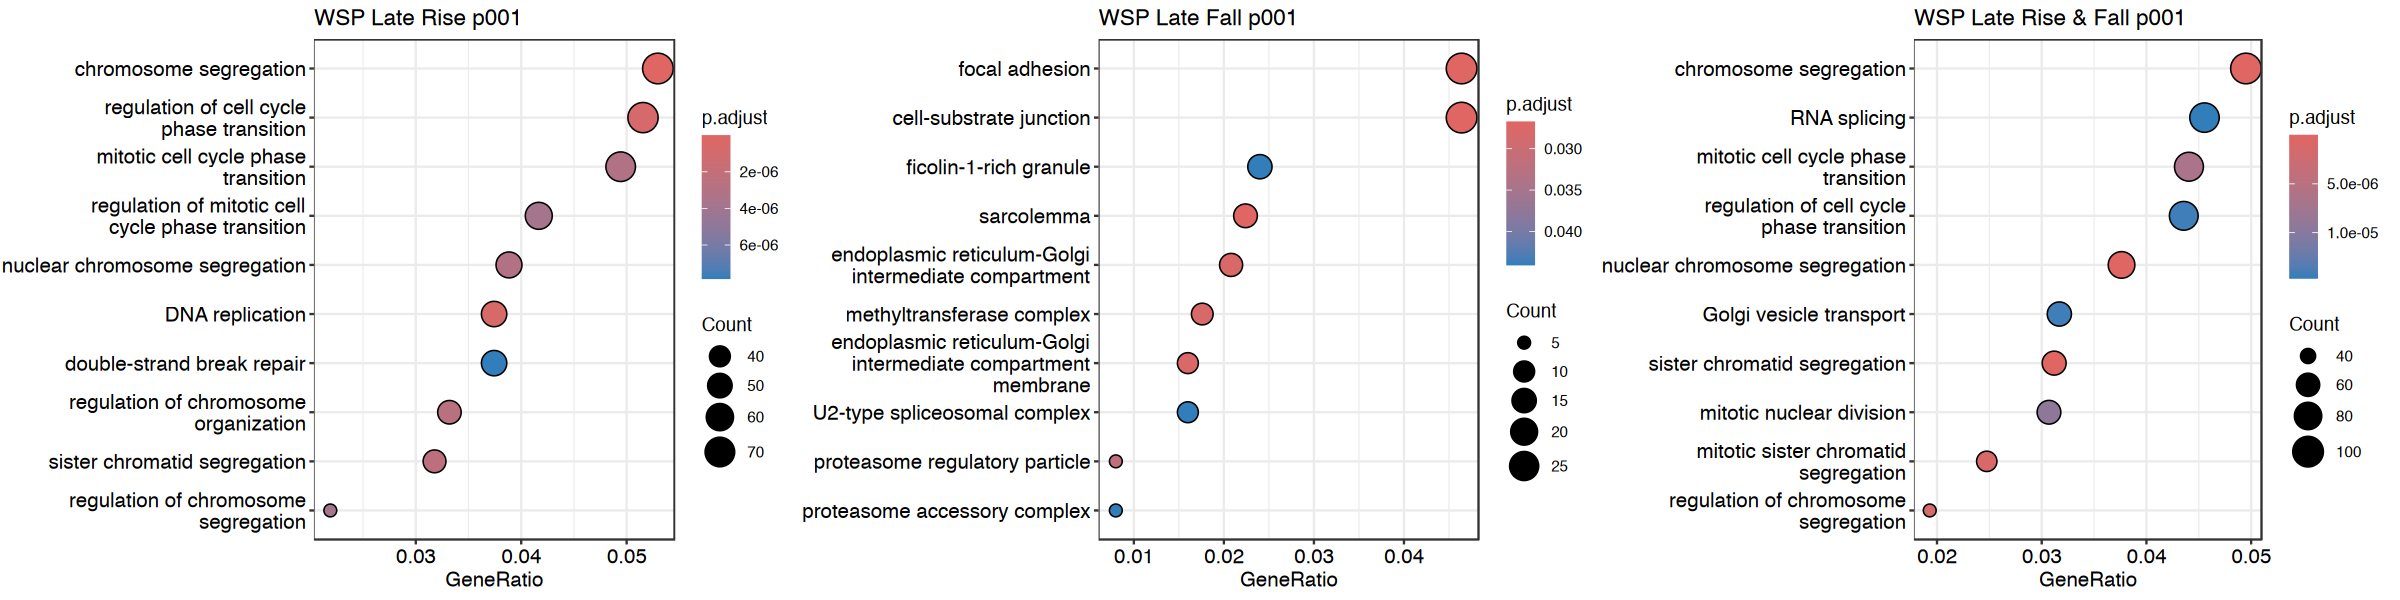

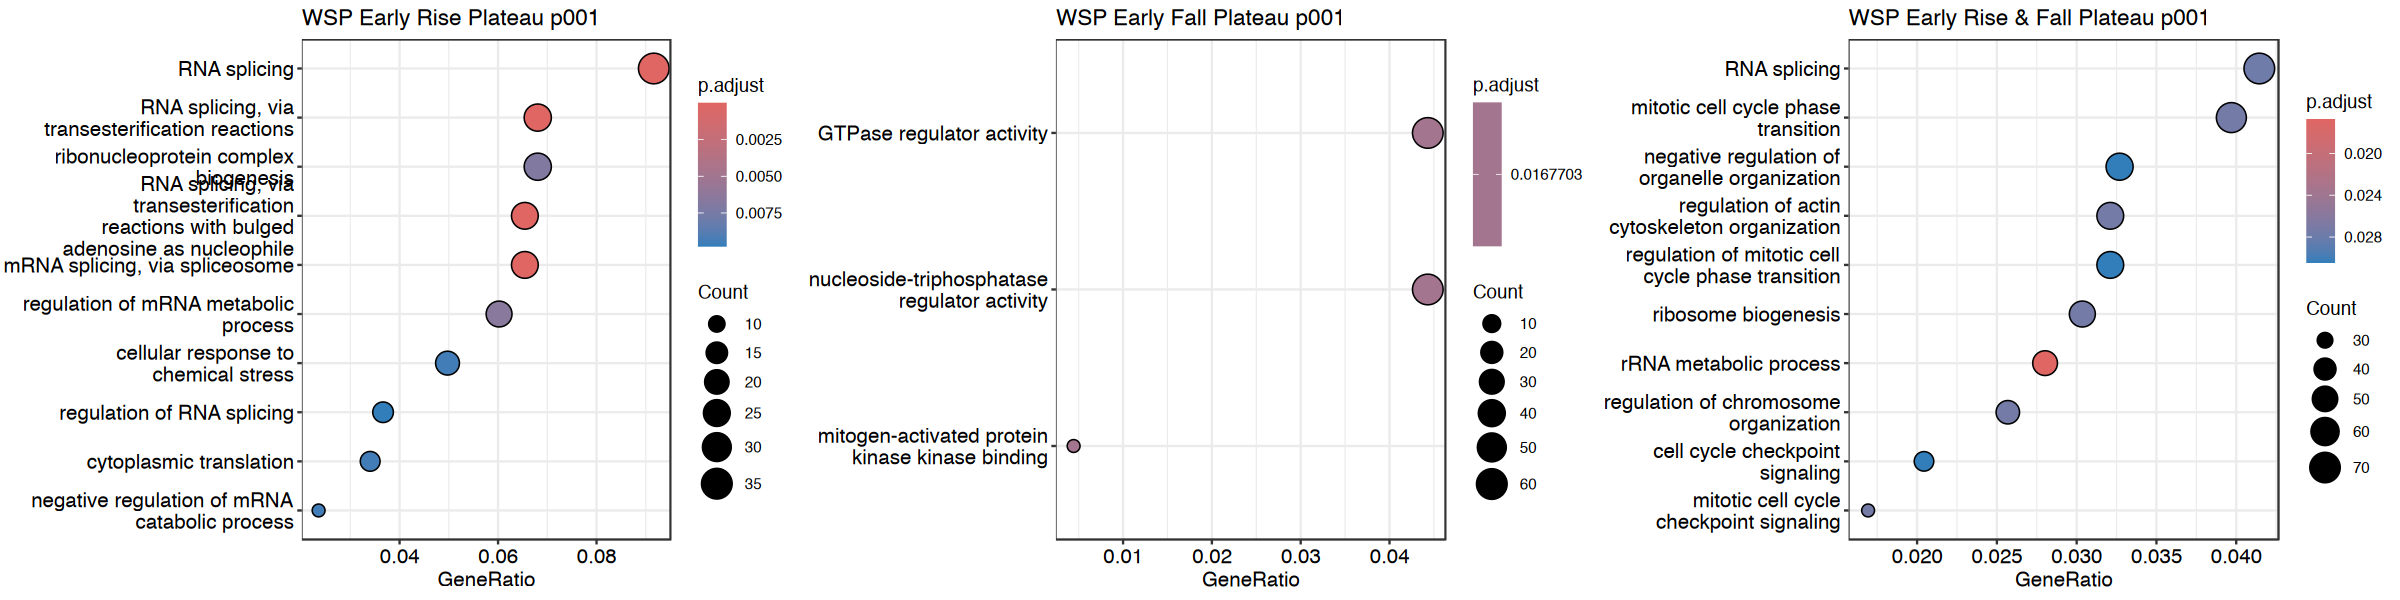

In [43]:
options(repr.plot.height=5, repr.plot.width=20)
pert="WSP"
p1 <- dotplot(go_early_rise, showCategory = 10, title=paste(pert,  "Early Rise p001"))
p2 <- dotplot(go_early_fall, showCategory = 10, title=paste(pert,  "Early Fall p001"))
p3 <- dotplot(go_early_both, showCategory = 10, title=paste(pert,  "Early Rise & Fall p001"))
grid.arrange(p1, p2, p3, ncol = 3)
# options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_late_up, showCategory = 10, title=paste(pert,  "Late Rise p001"))
p2 <- dotplot(go_late_down, showCategory = 10, title=paste(pert,  "Late Fall p001"))
p3 <- dotplot(go_late_both, showCategory = 10, title=paste(pert,  "Late Rise & Fall p001"))
grid.arrange(p1, p2, p3, ncol = 3)
options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_early_plat_up, showCategory = 10, title=paste(pert,  "Early Rise Plateau p001"))
p2 <- dotplot(go_early_plat_down, showCategory = 10, title=paste(pert,  "Early Fall Plateau p001"))
p3 <- dotplot(go_early_plat_both, showCategory = 10, title=paste(pert,  "Early Rise & Fall Plateau p001"))
grid.arrange(p1, p2, p3, ncol = 3)

In [44]:
write.table(go_early_rise, paste0("../results/GO/p001_GO_EarlyRise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_early_fall, paste0("../results/GO/p001_GO_EarlyFall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_late_up, paste0("../results/GO/p001_GO_LateRise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_late_down, paste0("../results/GO/p001_GO_LateFall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_early_plat_up, paste0("../results/GO/p001_GO_EarlyRisePlat", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)

saveRDS(All_Sig_genes, paste0(results_dir, "WSP_siggenes_DESeq2_GeneHK_p001.rds"))
saveRDS(All_Sig_nontss, paste0(results_dir, "WSP_signontss_DESeq2_GeneHK_p001.rds"))

## Adj pval of 1e-10

[1] "WSP30 vs Veh"

out of 18613 with nonzero total read count
adjusted p-value < 1e-10
LFC > 0 (up)       : 1054, 5.7%
LFC < 0 (down)     : 3926, 21%
outliers [1]       : 0, 0%
low counts [2]     : 1083, 5.8%
(mean count < 21)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



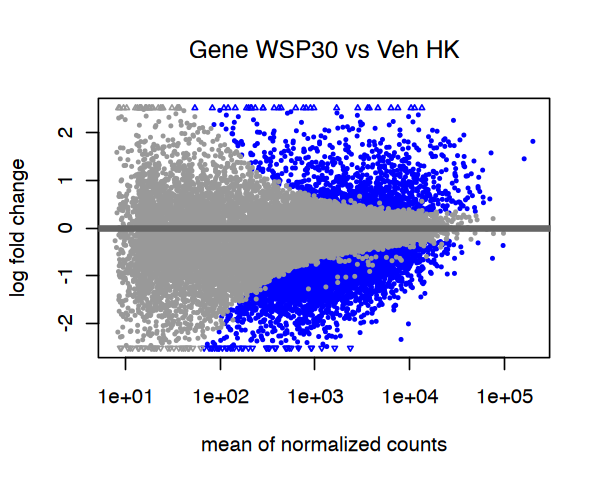

[1] 1054

[1] 3926

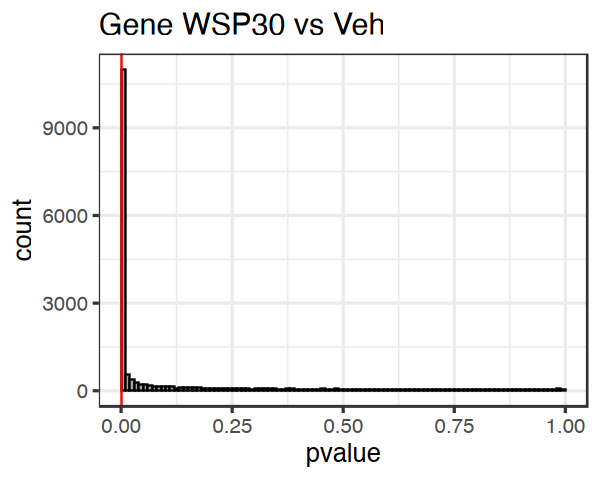

[1] "WSP120 vs Veh"

out of 18613 with nonzero total read count
adjusted p-value < 1e-10
LFC > 0 (up)       : 1615, 8.7%
LFC < 0 (down)     : 2777, 15%
outliers [1]       : 0, 0%
low counts [2]     : 2887, 16%
(mean count < 59)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



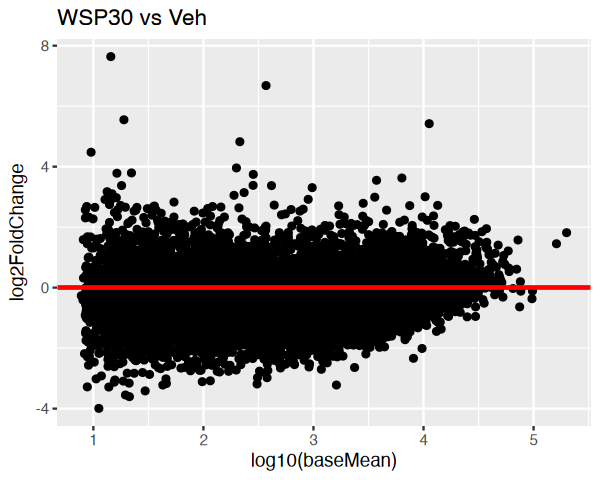

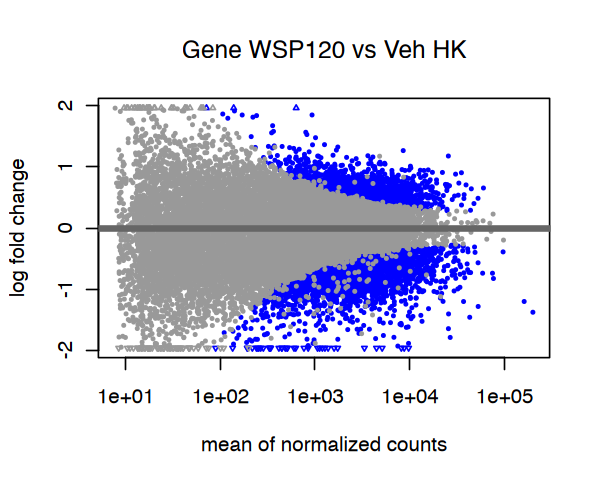

[1] 1615

[1] 2777

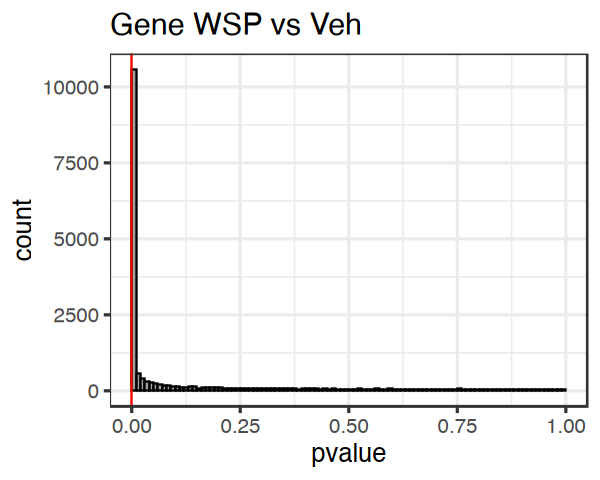

[1] "WSP120 vs WSP30"

out of 18613 with nonzero total read count
adjusted p-value < 1e-10
LFC > 0 (up)       : 3783, 20%
LFC < 0 (down)     : 1542, 8.3%
outliers [1]       : 0, 0%
low counts [2]     : 1083, 5.8%
(mean count < 21)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



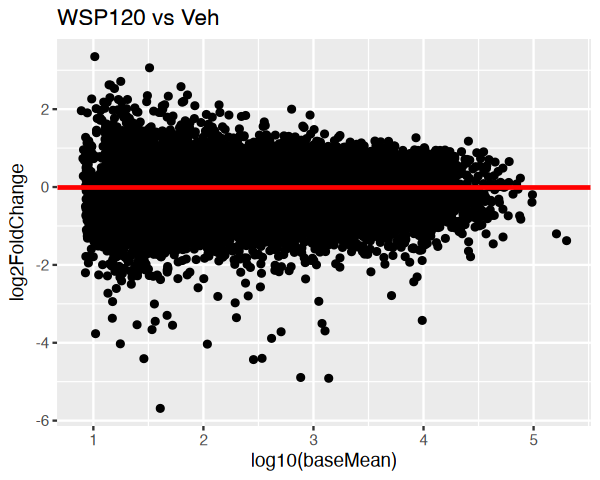

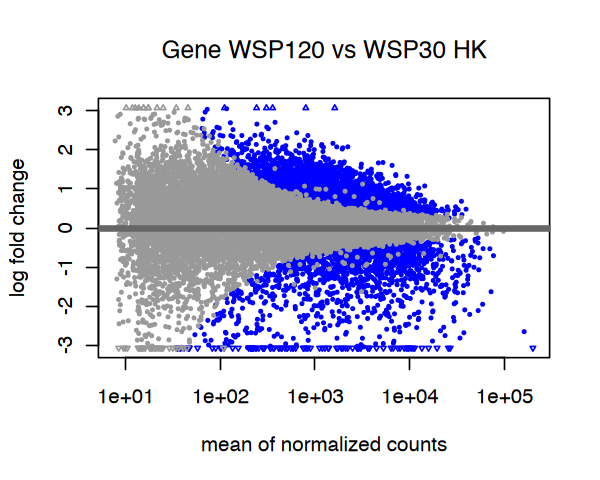

[1] 3783

[1] 1542

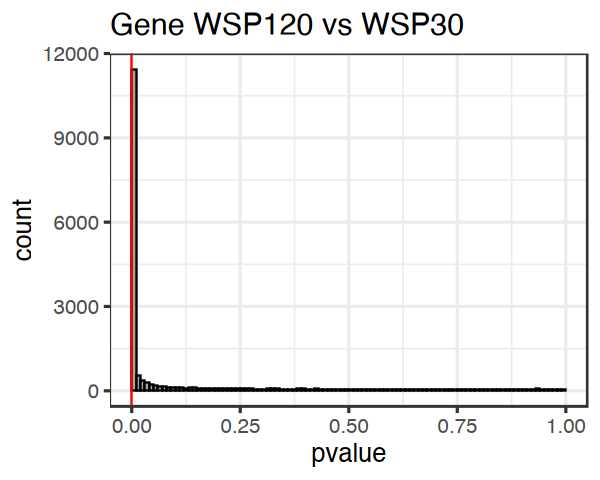

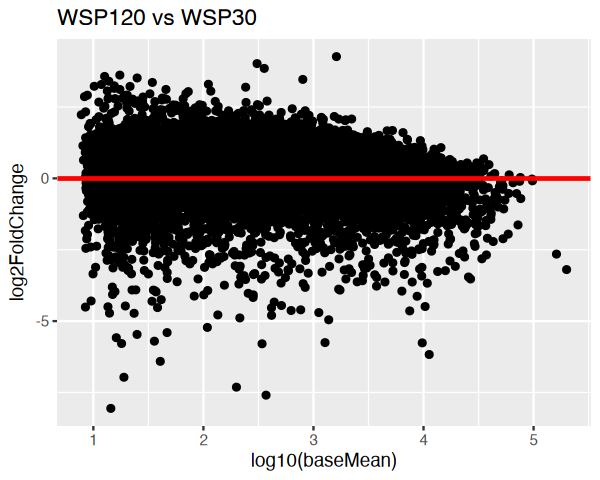

In [57]:
# Gene Results
padj_threshold=0.0000000001
binwidth_use = 0.01
print("WSP30 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP30", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP30 vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP30 vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P30_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P30_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P30_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P30_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP30 vs Veh")


print("WSP120 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP120", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP120 vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P120_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P120_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P120_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P120_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP120 vs Veh")



print("WSP120 vs WSP30")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP120", "WSP30"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP120 vs WSP30 HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP120 vs WSP30")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P120_vs_P30"]] = up_sig_genes
All_Sig_genes[["P120_vs_P30_up"]] = up_sig_genes
Down_Sig_genes[["P120_vs_P30"]] = down_sig_genes
All_Sig_genes[["P120_vs_P30_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP120 vs WSP30")




In [61]:
## EARLY and Temporary
early_rise_genes = setdiff(intersect(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P120_vs_P30"]]), 
                           union(Up_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_Veh"]]))
length(early_rise_genes)
go_early_rise = run_go_analysis(early_rise_genes)
early_fall_genes = setdiff(intersect(Down_Sig_genes[["P30_vs_Veh"]], Up_Sig_genes[["P120_vs_P30"]]), 
                           union(Up_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_Veh"]]))
length(early_fall_genes)
go_early_fall = run_go_analysis(early_fall_genes)
go_early_both = run_go_analysis(union(early_rise_genes, early_fall_genes))

[1] 416

[1] 1527

In [62]:
## Early and stays (plateaus)
early_plat_up = setdiff(intersect(Up_Sig_genes[["P120_vs_Veh"]], Up_Sig_genes[["P30_vs_Veh"]]), 
                    union(Up_Sig_genes[["P120_vs_P30"]], Down_Sig_genes[["P120_vs_P30"]]))
length(early_plat_up)
go_early_plat_up = run_go_analysis(early_plat_up)
early_plat_down = setdiff(intersect(Down_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]), 
                    union(Up_Sig_genes[["P120_vs_P30"]], Down_Sig_genes[["P120_vs_P30"]]))
length(early_plat_down)
go_early_plat_down = run_go_analysis(early_plat_down)
go_early_plat_both = run_go_analysis(union(early_plat_up, early_plat_down))

[1] 164

[1] 1148

In [63]:
## LATE
late_up = setdiff(intersect(Up_Sig_genes[["P120_vs_Veh"]], Up_Sig_genes[["P120_vs_P30"]]), 
                    union(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]))
length(late_up)
go_late_up = run_go_analysis(late_up)
late_down = setdiff(intersect(Down_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_P30"]]), 
                    union(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]))
length(late_down)
go_late_down = run_go_analysis(late_down)
go_late_both = run_go_analysis(union(late_up, late_down))

[1] 879

[1] 549

#### GO Term Numbers
* Early Rise: 416 genes, 775 enriched terms
* Early Fall: 1527 genes, 40 enriched terms
* Late Up: 879 genes, 219 enriched terms
* Late Down: 549 genes, 11 enriched terms
* Early Plateau Up: 164 genes, 53 enriched terms
* Early Plateau Down: 1148 genes, 56 enriched terms

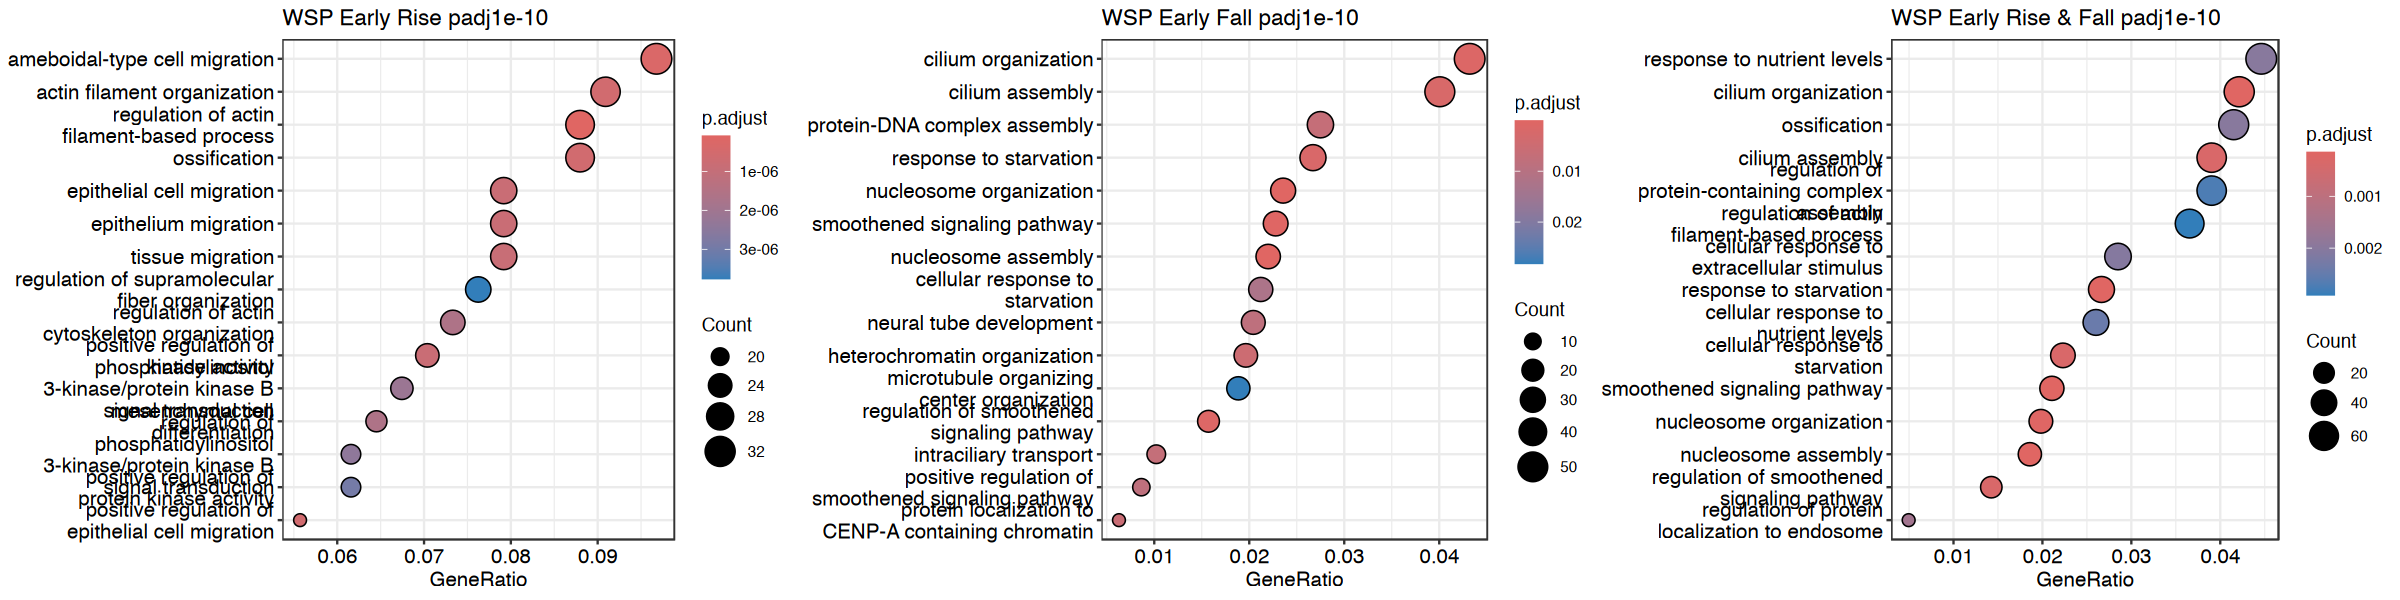

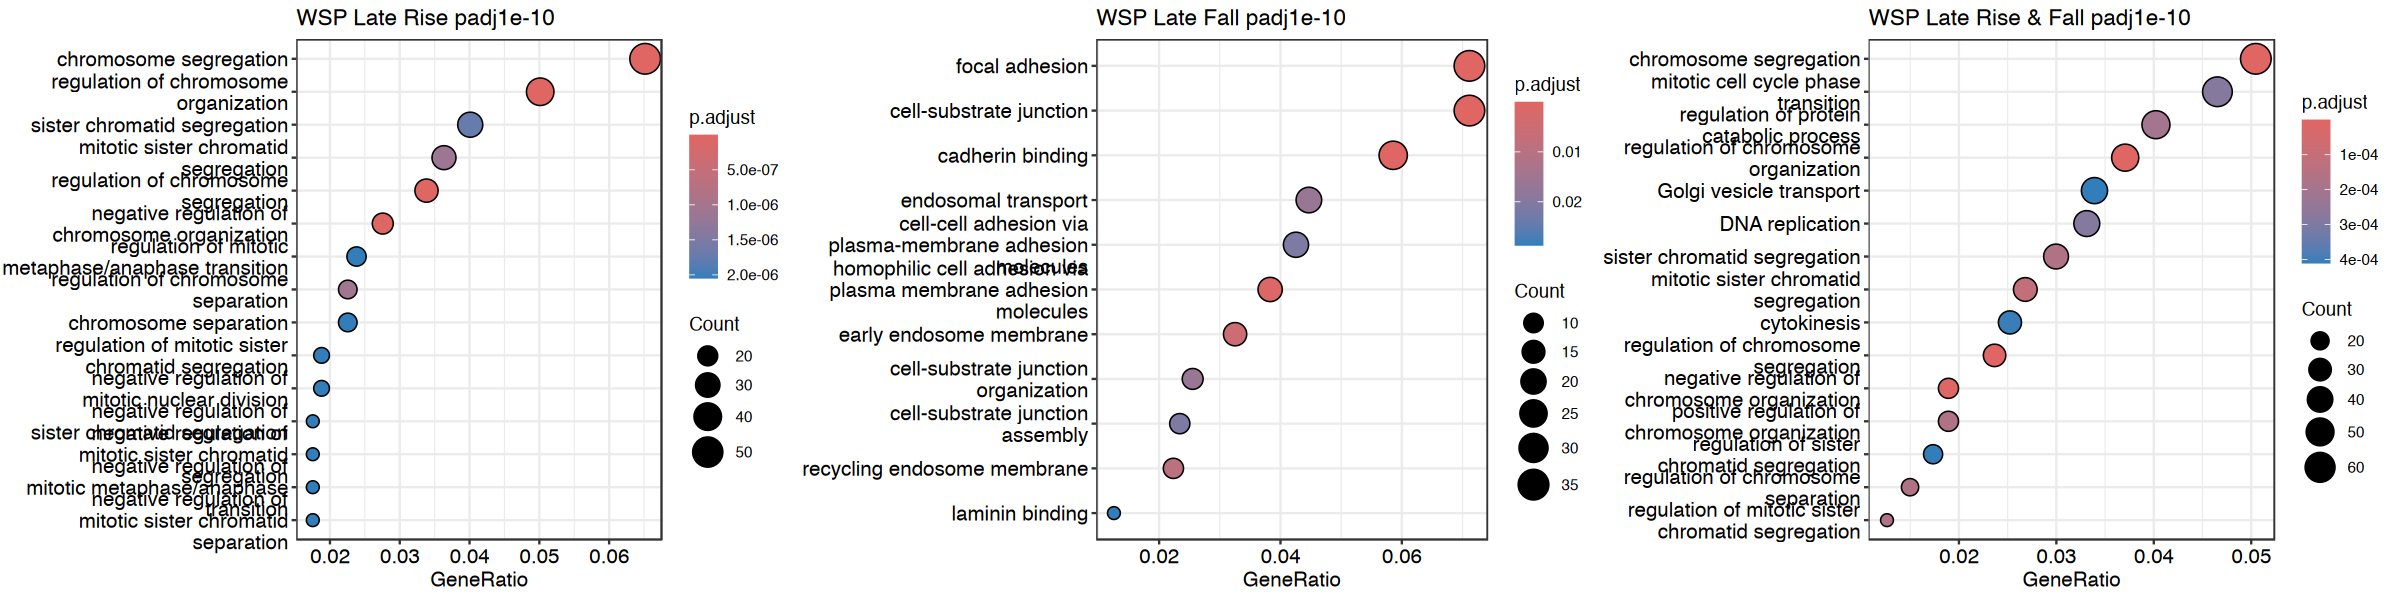

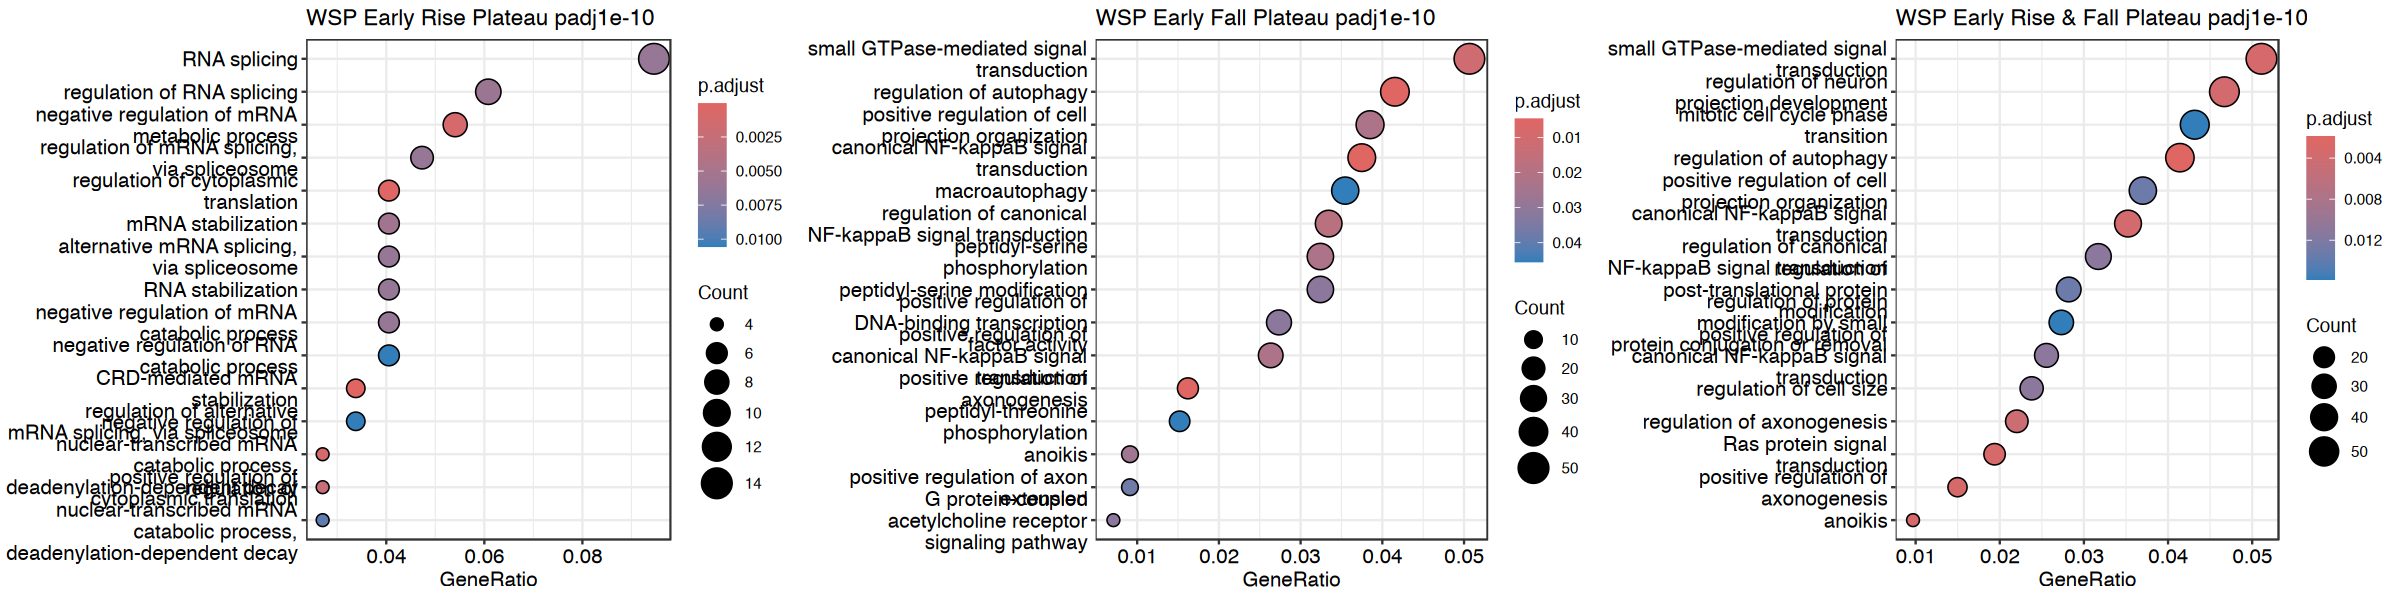

In [73]:
options(repr.plot.height=5, repr.plot.width=20)
pert="WSP"
p1 <- dotplot(go_early_rise, showCategory = 15, title=paste(pert,  "Early Rise padj1e-10"))
p2 <- dotplot(go_early_fall, showCategory = 15, title=paste(pert,  "Early Fall padj1e-10"))
p3 <- dotplot(go_early_both, showCategory = 15, title=paste(pert,  "Early Rise & Fall padj1e-10"))
grid.arrange(p1, p2, p3, ncol = 3)
# options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_late_up, showCategory = 15, title=paste(pert,  "Late Rise padj1e-10"))
p2 <- dotplot(go_late_down, showCategory = 15, title=paste(pert,  "Late Fall padj1e-10"))
p3 <- dotplot(go_late_both, showCategory = 15, title=paste(pert,  "Late Rise & Fall padj1e-10"))
grid.arrange(p1, p2, p3, ncol = 3)
options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_early_plat_up, showCategory = 15, title=paste(pert,  "Early Rise Plateau padj1e-10"))
p2 <- dotplot(go_early_plat_down, showCategory = 15, title=paste(pert,  "Early Fall Plateau padj1e-10"))
p3 <- dotplot(go_early_plat_both, showCategory = 15, title=paste(pert,  "Early Rise & Fall Plateau padj1e-10"))
grid.arrange(p1, p2, p3, ncol = 3)

In [74]:
write.table(go_early_rise, paste0("../results/GO/p1e10_GO_EarlyRise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_early_fall, paste0("../results/GO/p1e10_GO_EarlyFall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_late_up, paste0("../results/GO/p1e10_GO_LateRise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_late_down, paste0("../results/GO/p1e10_GO_LateFall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_early_plat_up, paste0("../results/GO/p1e10_GO_EarlyRisePlat", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_early_plat_down, paste0("../results/GO/p1e10_GO_EarlyFallPlat", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)

saveRDS(All_Sig_genes, paste0(results_dir, "WSP_siggenes_DESeq2_GeneHK_p1e10.rds"))
saveRDS(All_Sig_nontss, paste0(results_dir, "WSP_signontss_DESeq2_GeneHK_p1e10.rds"))

## Adj pval of 1e-20

[1] "WSP30 vs Veh"

out of 18613 with nonzero total read count
adjusted p-value < 1e-20
LFC > 0 (up)       : 682, 3.7%
LFC < 0 (down)     : 2253, 12%
outliers [1]       : 0, 0%
low counts [2]     : 1805, 9.7%
(mean count < 33)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



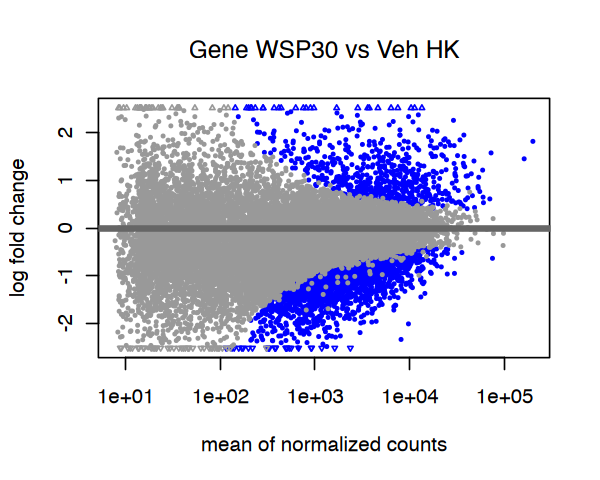

[1] 682

[1] 2253

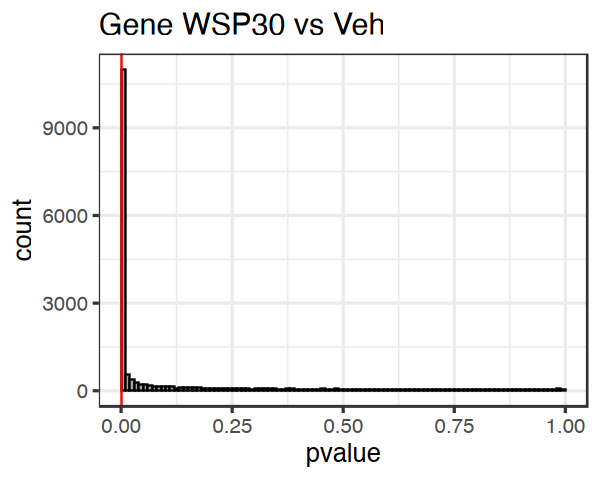

[1] "WSP120 vs Veh"

out of 18613 with nonzero total read count
adjusted p-value < 1e-20
LFC > 0 (up)       : 606, 3.3%
LFC < 0 (down)     : 1581, 8.5%
outliers [1]       : 0, 0%
low counts [2]     : 3248, 17%
(mean count < 71)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



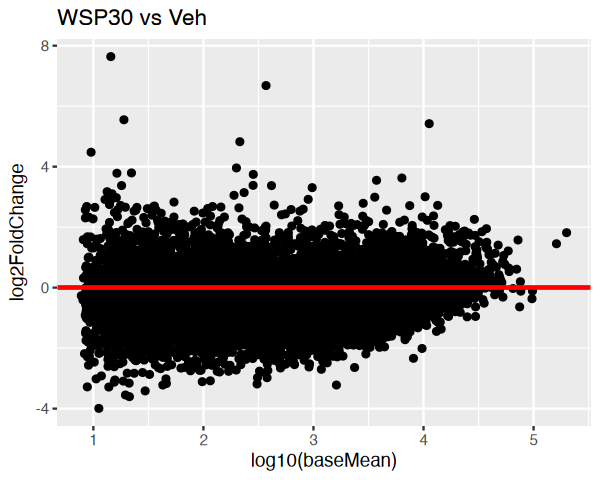

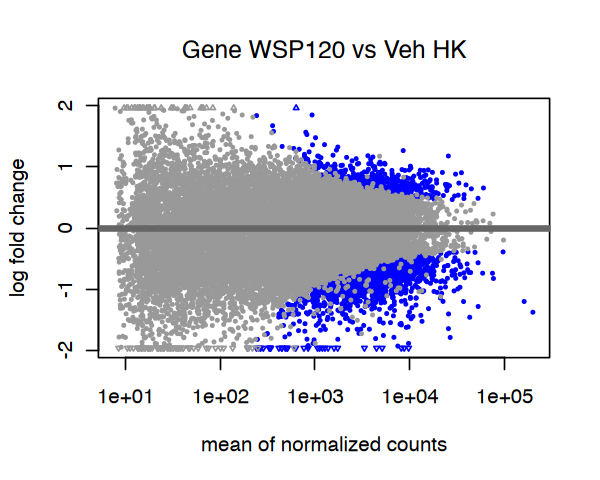

[1] 606

[1] 1581

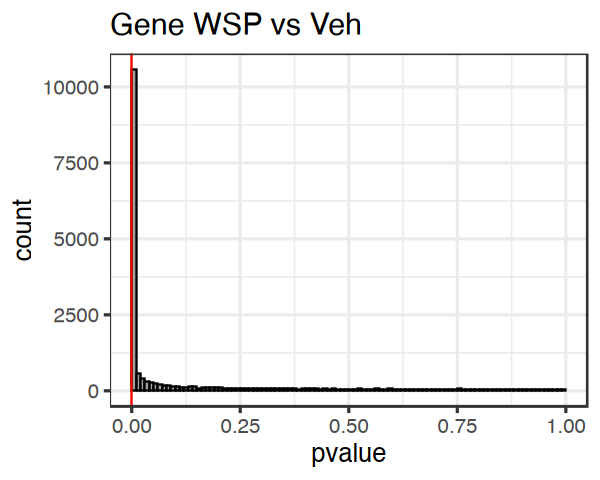

[1] "WSP120 vs WSP30"

out of 18613 with nonzero total read count
adjusted p-value < 1e-20
LFC > 0 (up)       : 1959, 11%
LFC < 0 (down)     : 1036, 5.6%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 8)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



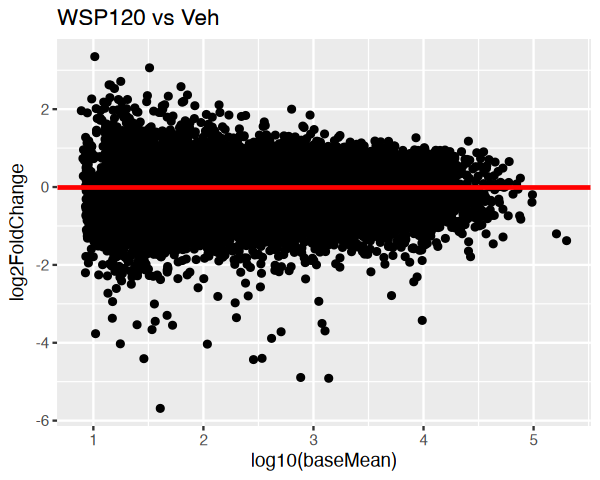

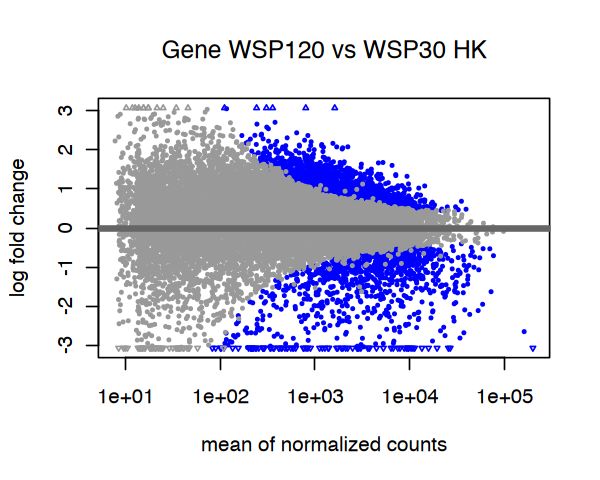

[1] 1959

[1] 1036

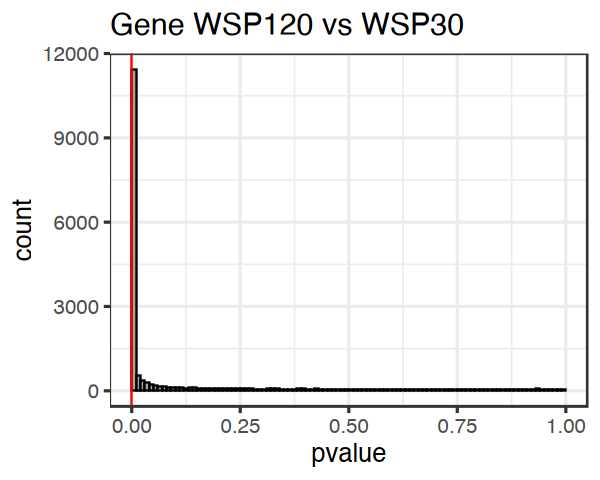

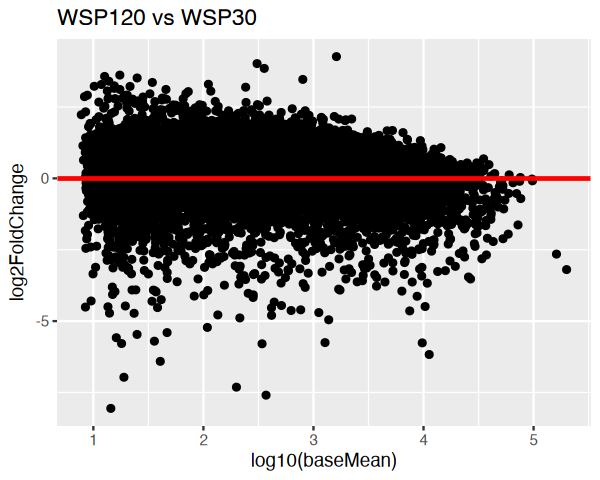

In [112]:
# Gene Results
padj_threshold=1e-20
binwidth_use = 0.01
print("WSP30 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP30", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP30 vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP30 vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P30_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P30_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P30_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P30_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP30 vs Veh")


print("WSP120 vs Veh")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP120", "VEH"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP120 vs Veh HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP vs Veh")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P120_vs_Veh"]] = up_sig_genes
All_Sig_genes[["P120_vs_Veh_up"]] = up_sig_genes
Down_Sig_genes[["P120_vs_Veh"]] = down_sig_genes
All_Sig_genes[["P120_vs_Veh_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP120 vs Veh")



print("WSP120 vs WSP30")
options(repr.plot.height=4, repr.plot.width=5)
gene_res = results(dds_gene_filt, contrast= c("Treatment", "WSP120", "WSP30"), alpha=padj_threshold)
gene_res <- gene_res[order(gene_res$pvalue),]
summary(gene_res)
plotMA(gene_res, main="Gene WSP120 vs WSP30 HK")
ggplot(data.frame(gene_res), aes(x=pvalue)) + geom_histogram(fill="grey64", binwidth=binwidth_use, color="black", boundary=0) + theme_bw(base_size=15) + 
       geom_vline(xintercept=padj_threshold, color="red") + ggtitle("Gene WSP120 vs WSP30")
up_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange > 0), ])
down_sig_genes <- rownames(gene_res[which(gene_res$padj < padj_threshold & gene_res$log2FoldChange < 0), ])
length(up_sig_genes); length(down_sig_genes)
Up_Sig_genes[["P120_vs_P30"]] = up_sig_genes
All_Sig_genes[["P120_vs_P30_up"]] = up_sig_genes
Down_Sig_genes[["P120_vs_P30"]] = down_sig_genes
All_Sig_genes[["P120_vs_P30_down"]] = down_sig_genes

testing = as.data.frame(gene_res)
ggplot(testing, aes(x=log10(baseMean), y=log2FoldChange)) + geom_point() + 
geom_hline(yintercept=0, color="red", size=1) + ggtitle("WSP120 vs WSP30")




In [113]:
## EARLY and Temporary
early_rise_genes = setdiff(intersect(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P120_vs_P30"]]), 
                           union(Up_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_Veh"]]))
length(early_rise_genes)
go_early_rise = run_go_analysis(early_rise_genes)
early_fall_genes = setdiff(intersect(Down_Sig_genes[["P30_vs_Veh"]], Up_Sig_genes[["P120_vs_P30"]]), 
                           union(Up_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_Veh"]]))
length(early_fall_genes)
go_early_fall = run_go_analysis(early_fall_genes)
go_early_both = run_go_analysis(union(early_rise_genes, early_fall_genes))

[1] 350

[1] 769

In [114]:
## Early and stays (plateaus)
early_plat_up = setdiff(intersect(Up_Sig_genes[["P120_vs_Veh"]], Up_Sig_genes[["P30_vs_Veh"]]), 
                    union(Up_Sig_genes[["P120_vs_P30"]], Down_Sig_genes[["P120_vs_P30"]]))
length(early_plat_up)
go_early_plat_up = run_go_analysis(early_plat_up)
early_plat_down = setdiff(intersect(Down_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]), 
                    union(Up_Sig_genes[["P120_vs_P30"]], Down_Sig_genes[["P120_vs_P30"]]))
length(early_plat_down)
go_early_plat_down = run_go_analysis(early_plat_down)
go_early_plat_both = run_go_analysis(union(early_plat_up, early_plat_down))

[1] 68

[1] 582

In [115]:
## LATE
late_up = setdiff(intersect(Up_Sig_genes[["P120_vs_Veh"]], Up_Sig_genes[["P120_vs_P30"]]), 
                    union(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]))
length(late_up)
go_late_up = run_go_analysis(late_up)
late_down = setdiff(intersect(Down_Sig_genes[["P120_vs_Veh"]], Down_Sig_genes[["P120_vs_P30"]]), 
                    union(Up_Sig_genes[["P30_vs_Veh"]], Down_Sig_genes[["P30_vs_Veh"]]))
length(late_down)
go_late_down = run_go_analysis(late_down)
go_late_both = run_go_analysis(union(late_up, late_down))

[1] 251

[1] 324

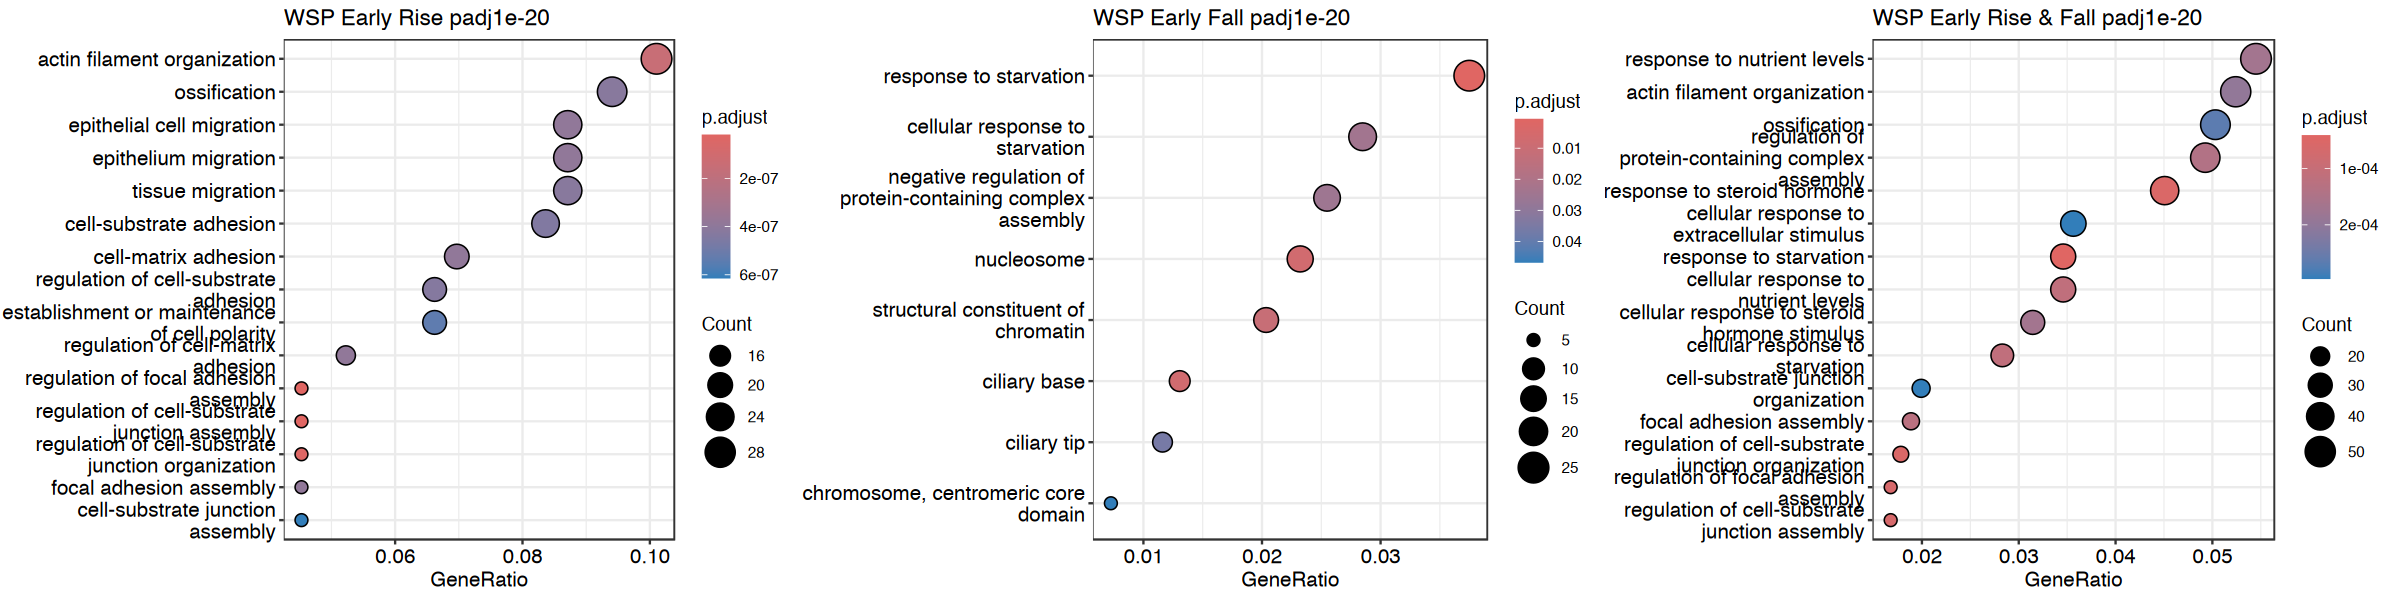

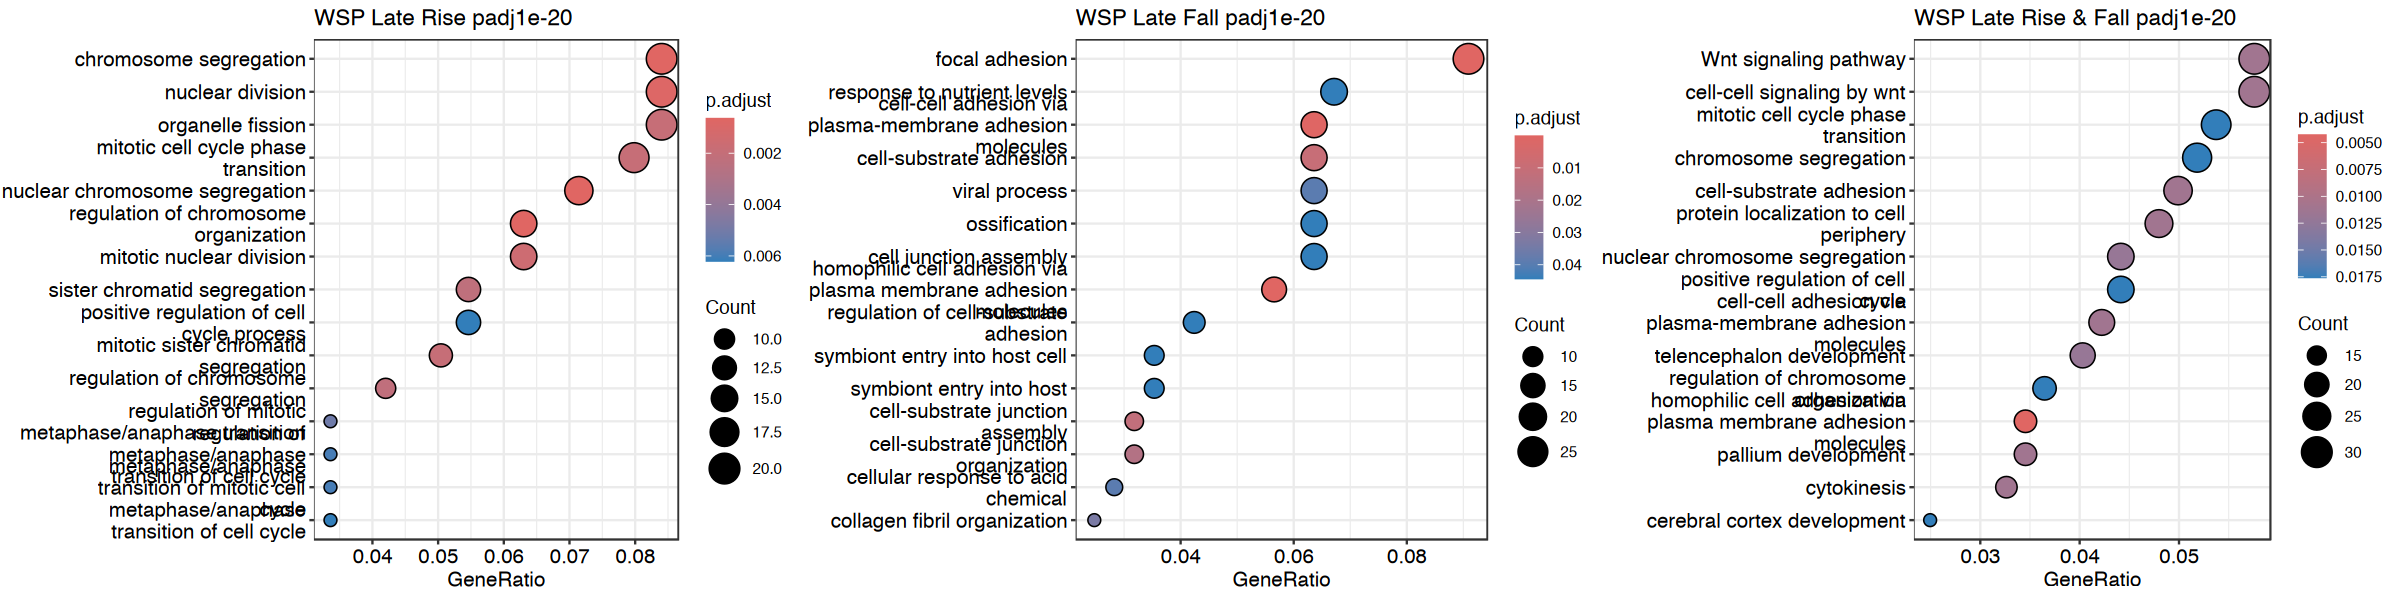

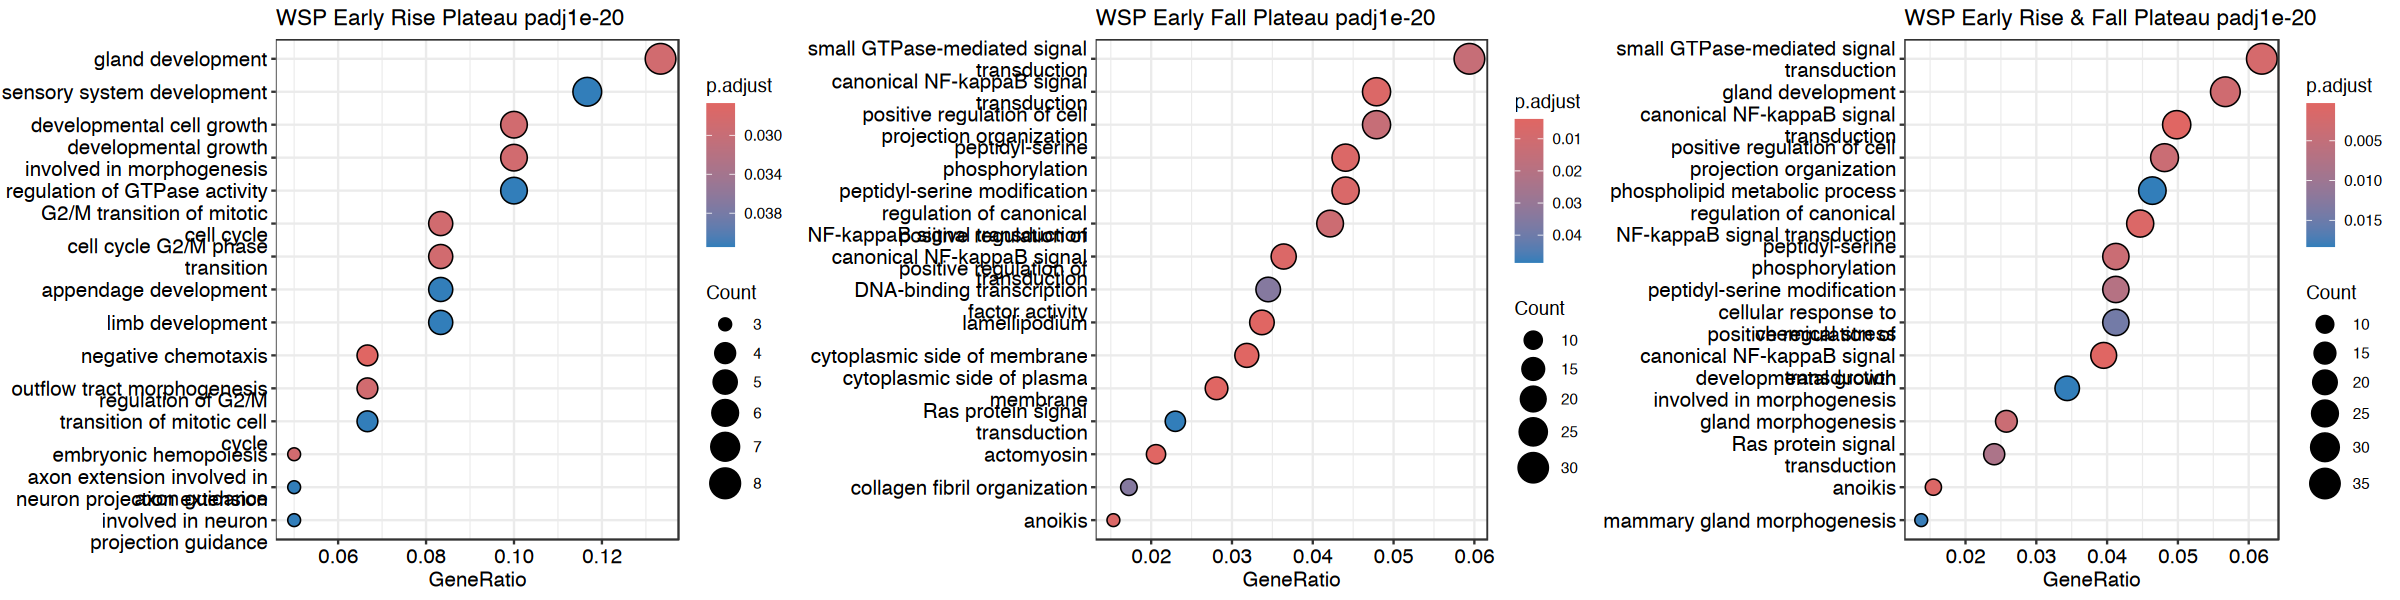

In [116]:
options(repr.plot.height=5, repr.plot.width=20)
pert="WSP"
p1 <- dotplot(go_early_rise, showCategory = 15, title=paste(pert,  "Early Rise padj1e-20"))
p2 <- dotplot(go_early_fall, showCategory = 15, title=paste(pert,  "Early Fall padj1e-20"))
p3 <- dotplot(go_early_both, showCategory = 15, title=paste(pert,  "Early Rise & Fall padj1e-20"))
grid.arrange(p1, p2, p3, ncol = 3)
# options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_late_up, showCategory = 15, title=paste(pert,  "Late Rise padj1e-20"))
p2 <- dotplot(go_late_down, showCategory = 15, title=paste(pert,  "Late Fall padj1e-20"))
p3 <- dotplot(go_late_both, showCategory = 15, title=paste(pert,  "Late Rise & Fall padj1e-20"))
grid.arrange(p1, p2, p3, ncol = 3)
options(repr.plot.height=5, repr.plot.width=20)
p1 <- dotplot(go_early_plat_up, showCategory = 15, title=paste(pert,  "Early Rise Plateau padj1e-20"))
p2 <- dotplot(go_early_plat_down, showCategory = 15, title=paste(pert,  "Early Fall Plateau padj1e-20"))
p3 <- dotplot(go_early_plat_both, showCategory = 15, title=paste(pert,  "Early Rise & Fall Plateau padj1e-20"))
grid.arrange(p1, p2, p3, ncol = 3)

In [117]:
pert
write.table(go_early_rise, paste0("../results/GO/p1e20_GO_EarlyRise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_early_fall, paste0("../results/GO/p1e20_GO_EarlyFall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_late_up, paste0("../results/GO/p1e20_GO_LateRise", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_late_down, paste0("../results/GO/p1e20_GO_LateFall", pert, "_DESeq2_GeneHK.txt"),, 
           sep="\t", quote=FALSE)
write.table(go_early_plat_up, paste0("../results/GO/p1e20_GO_EarlyRisePlat", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)
write.table(go_early_plat_down, paste0("../results/GO/p1e20_GO_EarlyFallPlat", pert, "_DESeq2_GeneHK.txt"), 
           sep="\t", quote=FALSE)

saveRDS(All_Sig_genes, paste0(results_dir, "WSP_siggenes_DESeq2_GeneHK_p1e20.rds"))

[1] "WSP"